# Coursework 2 

## Solar power prediction

0: Recurrent function definitions

1: Data preprocessing and engineering for single-cell and multi-cell prediction

2: Models - The three models used througout the notebook

3: Single cell prediction for UG Hall7 site - 15 minuite time horizon

4: Single cell prediction for UG Hall7 site - 24 hour time horizon

5: Generalised model for multi cell prediction

6: Comparison with naive baseline

## 0

In [39]:
# Importing the relevant libraries

import pandas as pd
import numpy as np
import os
import re
import glob
import difflib
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from concurrent.futures import ThreadPoolExecutor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import optuna
from optuna import visualization as vis
from optuna.trial import TrialState
import seaborn as sns
import json

# Seed for reproducibility

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

In [40]:
# Dataloader function
def create_dataloaders(
    df,
    target_col='power(W)',
    exclude_cols=['generation(kWh)'],
    seq_length=48,
    pred_length=1,
    train_end_date='2023-01-01',
    test_end_date='2023-06-01',
    batch_size=64,
    shuffle_train=True,
    pin_memory=False,
    num_workers=0
):
    df_copy = df.copy()
    
    if not pd.api.types.is_datetime64_any_dtype(df_copy.index):
        df_copy.index = pd.to_datetime(df_copy.index, format='mixed', dayfirst=True)

    features = [col for col in df_copy.columns if col not in exclude_cols]
    target_idx = features.index(target_col)

    # scale the data - crucuially only on the training set - no data leakage
    scaler = MinMaxScaler()
    train_df = df_copy[df_copy.index < train_end_date]
    scaler.fit(train_df[features].values)

    scaled_data = scaler.transform(df_copy[features].values)

    xs, ys, indices = [], [], []
    
    # window correctly
    for i in range(len(scaled_data) - seq_length - pred_length + 1):
        xs.append(scaled_data[i : i + seq_length])

        ys.append(scaled_data[i + seq_length : i + seq_length + pred_length, target_idx])
        
        indices.append(df_copy.index[i + seq_length])

    X, y = np.array(xs), np.array(ys)
    dates = pd.DatetimeIndex(indices)

    t_split = pd.Timestamp(train_end_date)
    v_split = pd.Timestamp(test_end_date)
    
    train_mask = dates < t_split
    test_mask = (dates >= t_split) & (dates < v_split)
    val_mask = dates >= v_split

    def to_tensor(mask):
        return (
            torch.tensor(X[mask], dtype=torch.float32),
            torch.tensor(y[mask], dtype=torch.float32) 
        )


    # turn to tensors and create dataloaders
    X_train, y_train = to_tensor(train_mask)
    X_test, y_test = to_tensor(test_mask)
    X_val, y_val = to_tensor(val_mask)

    train_loader = DataLoader(
        TensorDataset(X_train, y_train), 
        batch_size=batch_size, 
        shuffle=shuffle_train, 
        pin_memory=pin_memory, 
        num_workers=num_workers
    )
    
    test_loader = DataLoader(
        TensorDataset(X_test, y_test), 
        batch_size=batch_size, 
        shuffle=False, 
        pin_memory=pin_memory, 
        num_workers=num_workers
    )
    
    val_loader = DataLoader(
        TensorDataset(X_val, y_val), 
        batch_size=batch_size, 
        shuffle=False, 
        pin_memory=pin_memory, 
        num_workers=num_workers
    )

    return train_loader, test_loader, val_loader, scaler, features, target_idx

In [41]:
# Dataloader function for generalised model 

def create_multicell_dataloaders(
    df,
    cell_id_col='Site_ID',
    target_col='power(W)',
    exclude_cols=['generation(kWh)'],
    seq_length=48,
    pred_length=96,
    train_start_date='2022-01-01',
    train_end_date='2023-01-01',
    test_end_date='2023-06-01',
    batch_size=64,
    scaler=None,
    shuffle_train=True,
    pin_memory=False,
    num_workers=0
):
    df_copy = df.copy()
    
    if not pd.api.types.is_datetime64_any_dtype(df_copy.index):
        df_copy.index = pd.to_datetime(df_copy.index, format='mixed', dayfirst=True)

    features = [col for col in df_copy.columns if col not in exclude_cols and col != cell_id_col]
    target_idx = features.index(target_col)

    # scale the data - crucuially only on the training set - no data leakage
    if scaler is None:
        scaler = MinMaxScaler()
        train_df = df_copy[(df_copy.index >= train_start_date) & (df_copy.index < train_end_date)]
        scaler.fit(train_df[features].values)

    df_copy[features] = scaler.transform(df_copy[features].values)

    xs, ys, indices = [], [], []
    
    # group by cell to prevent boundary crossing
    for cell_id, group_df in df_copy.groupby(cell_id_col):
    
        group_df = group_df.sort_index() 
        
        group_data = group_df[features].values
        group_dates = group_df.index
        
        for i in range(len(group_data) - seq_length - pred_length + 1):
            xs.append(group_data[i : i + seq_length])
            ys.append(group_data[i + seq_length : i + seq_length + pred_length, target_idx])
            indices.append(group_dates[i + seq_length])

    X, y = np.array(xs), np.array(ys)
    dates = pd.DatetimeIndex(indices)

    # split by date and then turn to tensors and create dataloaders
    t_split = pd.Timestamp(train_end_date)
    v_split = pd.Timestamp(test_end_date)
    
    train_mask = dates < t_split
    test_mask = (dates >= t_split) & (dates < v_split)
    val_mask = dates >= v_split

    def to_tensor(mask):
        return (
            torch.tensor(X[mask], dtype=torch.float32),
            torch.tensor(y[mask], dtype=torch.float32) 
        )

    X_train, y_train = to_tensor(train_mask)
    X_test, y_test = to_tensor(test_mask)
    X_val, y_val = to_tensor(val_mask)

    train_loader = DataLoader(
        TensorDataset(X_train, y_train), 
        batch_size=batch_size, 
        shuffle=shuffle_train, 
        pin_memory=pin_memory, 
        num_workers=num_workers
    )
    
    test_loader = DataLoader(
        TensorDataset(X_test, y_test), 
        batch_size=batch_size, 
        shuffle=False, 
        pin_memory=pin_memory, 
        num_workers=num_workers
    )
    
    val_loader = DataLoader(
        TensorDataset(X_val, y_val), 
        batch_size=batch_size, 
        shuffle=False, 
        pin_memory=pin_memory, 
        num_workers=num_workers
    )

    return train_loader, test_loader, val_loader, scaler, features, target_idx

In [42]:
# Training function

import copy

"""

Cell generated by Gemini 3.1 Pro using prompt:

'I want to combine my training into a single function so that I can train 
multiple models within my notebook without having to rewrite the training script.
I want it to be generalisable though, make it have as many parameters as possible
even though most can be goven default values'

It was further edited by me

"""

def train_model(
    model,
    train_loader,
    test_loader=None,
    val_loader=None,
    fusion_mode = False,
    criterion=None,
    optimizer_class=torch.optim.Adam,
    lr=0.001,
    weight_decay=0.0,
    epochs=50,
    device='cpu',
    patience=5,
    save_best_model=True,
    model_save_path="best_model.pth",
    verbose=1,
    optuna_trial=None
):
    """
    A highly generalized PyTorch training loop for time-series models.
    
    Parameters:
    - model: The PyTorch neural network to train.
    - train_loader: DataLoader for the training set.
    - val_loader: DataLoader for the validation set (used for early stopping).
    - criterion: Loss function (defaults to nn.MSELoss()).
    - optimizer_class: The PyTorch optimizer class (defaults to Adam).
    - lr: Learning rate.
    - weight_decay: L2 regularization penalty (helps prevent overfitting).
    - epochs: Maximum number of epochs to train.
    - device: 'cuda' or 'cpu'. Defaults to auto-detect.
    - patience: Epochs to wait for improvement before Early Stopping (Set to None to disable).
    - save_best_model: Whether to save the weights of the lowest val_loss epoch.
    - model_save_path: Filepath to save the best model weights.
    - gradient_clip: Max norm for gradients (prevents exploding gradients in LSTMs).
    - verbose: How often to print epoch updates (1 = every epoch, 0 = silent).
    - optuna_trial: Pass the `trial` object if running inside an Optuna sweep for pruning.
    
    Returns:
    - model: The trained model (loaded with the best weights if early stopping triggered).
    - history: Dictionary containing lists of 'train_loss' and 'val_loss' over epochs.
    """
    
    # --- 1. Initialization ---
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    model = model.to(device)
    
    if criterion is None:
        criterion = nn.MSELoss()
        
    optimizer = optimizer_class(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {'train_loss': [], 'test_loss': []}
    best_test_loss = float('inf')
    trigger_times = 0

    best_model_weights = copy.deepcopy(model.state_dict())
    
    if verbose > 0:
        print(f"Starting training on {device} for up to {epochs} epochs...")



    # --- 2. Main Epoch Loop ---
    for epoch in range(epochs):
        # 1. Training Phase
        model.train()
        train_loss = 0.0

        if fusion_mode is False:
            for inputs, targets in train_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                loss.backward()
                optimizer.step()
                train_loss += loss.item() * inputs.size(0)
        else:
            for x_dyn, x_stat, targets in train_loader:
                x_dyn, x_stat, targets = x_dyn.to(device), x_stat.to(device), targets.to(device)
                optimizer.zero_grad()
                outputs = model(x_dyn, x_stat)
                loss = criterion(outputs, targets)
                loss.backward()
                optimizer.step()
                train_loss += loss.item() * x_dyn.size(0)

            
        train_loss = train_loss / len(train_loader.dataset)

        eval_metric = nn.L1Loss()
            
        # 2. Testing/Monitoring Phase (Per Epoch)
        model.eval()
        test_loss = 0.0
        with torch.no_grad():

            if fusion_mode is False:
                for inputs, targets in test_loader:
                    inputs, targets = inputs.to(device), targets.to(device)
                    outputs = model(inputs)
                    test_loss += eval_metric(outputs, targets).item() * inputs.size(0)
            else:
                for x_dyn, x_stat, targets in test_loader:
                    x_dyn, x_stat, targets = x_dyn.to(device), x_stat.to(device), targets.to(device)
                    outputs = model(x_dyn, x_stat)
                    test_loss += eval_metric(outputs, targets).item() * x_dyn.size(0)
                
        test_loss = test_loss / len(test_loader.dataset)
        
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)


        # -- Logging --
        if verbose > 0:
            log_msg = f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.6f}"
            if test_loss is not None:
                log_msg += f" | Test Loss: {test_loss:.6f}"
            print(log_msg)
            
        # -- Optuna Pruning --
        if optuna_trial is not None and test_loss is not None:
            optuna_trial.report(test_loss, epoch)
            if optuna_trial.should_prune():
                if verbose > 0:
                    print(f"Trial pruned by Optuna at epoch {epoch+1}")
                raise optuna.TrialPruned()
                
        # -- Early Stopping & Model Checkpointing --
        if test_loss is not None:
            if test_loss < best_test_loss:
                best_test_loss = test_loss
                trigger_times = 0
                if save_best_model:
                    best_model_weights = copy.deepcopy(model.state_dict())
            else:
                trigger_times += 1
                if patience is not None and trigger_times >= patience:
                    if verbose > 0:
                        print(f"Early stopping triggered! No improvement for {patience} epochs.")
                        break

                    

    # --- 3. Finalization ---
    # Load the best weights back into the model before returning it
    if save_best_model and test_loader is not None:
        model.load_state_dict(best_model_weights)
        if verbose > 0:
            print(f"Restored best model weights (Test Loss: {best_test_loss:.6f})")
            
    return model, history


In [60]:
# Optuna tuning function

def objective(trial, model_name, pred_length=96, fusion_mode=False):


    # --- DEFINE HYPERPARAMETER SEARCH SPACE ---

    rnn_type = trial.suggest_categorical("rnn_type", ["GRU", "LSTM"])
    num_layers = trial.suggest_int("num_layers", 1, 2)
    hidden_size = trial.suggest_categorical("hidden_size",[32, 64, 128])
    dropout = trial.suggest_float("dropout", 0.1, 0.4) if num_layers > 1 else 0.0
    seq_length = trial.suggest_categorical("seq_length",[24, 48, 96, 144, 192, 384])
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    loss_type = trial.suggest_categorical("loss_type", ["MSE", "MAE", "Huber"])

    if fusion_mode == True:
        fusion_type = trial.suggest_categorical("fusion_type", ["LateFusion", "FiLM"])
        lstm_hidden = trial.suggest_categorical("lstm_hidden", [32, 64, 128, 256])
        if fusion_type == "LateFusion":
            mlp_hidden = trial.suggest_categorical("mlp_hidden",[8, 16, 32, 64])
            model = LateFusionModel(dyn_size, stat_size, lstm_hidden, mlp_hidden, pred_length=pred_length, rnn_type=rnn_type, dropout=dropout).to(device)
        else:
            model = FiLMModel(dyn_size, stat_size, lstm_hidden, pred_length=pred_length, rnn_type=rnn_type, dropout=dropout).to(device)
    else:
        model = model_name(INPUT_SIZE, hidden_size, num_layers, rnn_type, dropout).to(device)
 
    if loss_type == "MSE":
        train_criterion = nn.MSELoss()
    elif loss_type == "MAE":
        train_criterion = nn.L1Loss()
    else:
        train_criterion = nn.HuberLoss()

    
    # --- BUILD DATALOADERS DYNAMICALLY ---
    if fusion_mode is False:
        train_dataset = DynamicSequenceDataset(train_scaled, seq_length, target_idx, pred_length)
        test_dataset = DynamicSequenceDataset(test_scaled, seq_length, target_idx, pred_length)
        val_dataset = DynamicSequenceDataset(val_scaled, seq_length, target_idx, pred_length)
    else:
        train_dataset = PVTimeSeriesDataset(train_df, dynamic_cols, static_cols, target_col, sequence_length=seq_length, pred_length=pred_length)
        test_dataset = PVTimeSeriesDataset(test_df, dynamic_cols, static_cols, target_col, sequence_length=seq_length, pred_length=pred_length)
        val_dataset = PVTimeSeriesDataset(val_df, dynamic_cols, static_cols, target_col, sequence_length=seq_length, pred_length=pred_length)


    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
    
    
    # --- TRAIN USING GENERALIZED FUNCTION ---
    trained_model, history = train_model(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        val_loader=val_loader, 
        fusion_mode = fusion_mode,
        criterion=train_criterion,
        lr=lr,
        epochs=10,
        device=device,
        patience=2,
        verbose=0, 
        optuna_trial=trial
    )

    # --- VALIDATE THE FINAL MODEL ---
    trained_model.eval()
    
    # ensure consistent scoring
    eval_criterion = nn.L1Loss() 
    val_loss_sum = 0.0
    
    with torch.no_grad():

        if fusion_mode is False:
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = trained_model(inputs)
                val_loss_sum += eval_criterion(outputs, targets).item() * inputs.size(0)
            
        else:
            for x_dyn, x_stat, targets in val_loader:
                x_dyn, x_stat, targets = x_dyn.to(device), x_stat.to(device), targets.to(device)
                outputs = trained_model(x_dyn, x_stat)
                val_loss_sum += eval_criterion(outputs, targets).item() * x_dyn.size(0) # CHECK THIS - used to be inputs.size(0), not sure if this is equivalent

    final_val_mae = val_loss_sum / len(val_dataset)
    
    return final_val_mae

In [44]:
# Reverses the scaling of the predictions

def unscale_power_values(preds, actuals, scaler, target_idx, num_features):
   
    dummy_preds = np.zeros((len(preds), num_features))
    dummy_actuals = np.zeros((len(actuals), num_features))
    
    dummy_preds[:, target_idx] = preds
    dummy_actuals[:, target_idx] = actuals
    
    preds_unscaled = scaler.inverse_transform(dummy_preds)[:, target_idx]
    actuals_unscaled = scaler.inverse_transform(dummy_actuals)[:, target_idx]
    
    preds_unscaled = np.maximum(preds_unscaled, 0)
    
    return preds_unscaled, actuals_unscaled

## 1 

Data engineering and preprocessing for both single-cell and multi-cell prediction

In [45]:
# Note: for this cell below the run time is really long - can it be improved and made more efficient?
# - answer: i think so, save xl file as a csv then call treat it as a standard csv

# Data engineering pipeline for single cell model
# uses the UG Hall 7 dataset - clean data

target_path = r"Dataset/Time series dataset/PV generation dataset/PV stations with panel level optimizer/Site level dataset/UG Hall7.csv"

ug_hall = pd.read_csv(target_path, parse_dates=['Time'])
ug_hall = ug_hall[(ug_hall['Time'] >= '2021-01-01') & (ug_hall['Time'] < '2024-01-01')]
ug_hall.set_index('Time', inplace=True)

# Resample target to 15-minute intervals - taking the mean
ug_hall = ug_hall.resample('15min').mean()

def process_weather_for_year(year):
    base_meteo_path = r"Dataset/Time series dataset/Meteorological dataset"
    
    # Mapping features to their specific folders and files
    files = {
        'Irradiance': os.path.join(base_meteo_path, 'Irradiance', f'Irradiance_{year}.csv'),
        'Relative Humidity': os.path.join(base_meteo_path, 'Relative Humidity', f'Relative Humidity_{year}.csv'),
        'Sea Level Pressure': os.path.join(base_meteo_path, 'Sea Level Pressure', f'Sea Level Pressure_{year}.csv'),
        'Temperature': os.path.join(base_meteo_path, 'Temperature', f'Temperature_{year}.csv'),
        'Visibility': os.path.join(base_meteo_path, 'Visibility', f'Visibility_{year}.csv'),
        'Wind': os.path.join(base_meteo_path, 'Wind', f'Wind_{year}.csv')
    }
    
    # Rainfall has a mix of Excel and CSV formats depending on the year
    if year == 2021:
        files['Rainfall'] = os.path.join(base_meteo_path, 'Rainfall', 'Rainfall_2021.xlsx')
    else:
        files['Rainfall'] = os.path.join(base_meteo_path, 'Rainfall', f'Rainfall_{year}.csv')

    dfs = []
    for feature, filepath in files.items():
        try:
            # Handle the 2021 Excel file anomaly
            if filepath.endswith('.xlsx'):
                df = pd.read_excel(filepath, parse_dates=['Time'])
            else:
                df = pd.read_csv(filepath, parse_dates=['Time'])
                
            df.set_index('Time', inplace=True)
            
            # Convert to numeric, coercing any weird string errors to NaN
            for col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
            
            # Resample: Rainfall needs to be Summed, everything else Averaged
            if feature == 'Rainfall':
                df = df.resample('15min').sum()
            else:
                df = df.resample('15min').mean()
                
            dfs.append(df)
        except Exception as e:
            print(f"Error loading {filepath}: {e}")
            
    # Concatenate all weather features for the year into one dataframe
    year_data = pd.concat(dfs, axis=1)
    return year_data

# Process weather for all 3 years
print("Processing weather data for 2021, 2022, and 2023...")
weather_2021 = process_weather_for_year(2021)
weather_2022 = process_weather_for_year(2022)
weather_2023 = process_weather_for_year(2023)

weather_all = pd.concat([weather_2021, weather_2022, weather_2023], axis=0)

# Merge Weather with Target Power Data
merged_all = pd.concat([ug_hall, weather_all], axis=1)

merged_all = merged_all['2021-01-01':'2023-12-31']

merged_all.dropna(inplace=True)

# Cyclical Time Encodings
merged_all['Month'] = merged_all.index.month
merged_all['Hour'] = merged_all.index.hour
merged_all['Minute'] = merged_all.index.minute

time_of_day = merged_all['Hour'] + merged_all['Minute'] / 60.0

merged_all['Month_Sin'] = np.sin(2 * np.pi * merged_all['Month'] / 12)
merged_all['Month_Cos'] = np.cos(2 * np.pi * merged_all['Month'] / 12)
merged_all['Time_Sin'] = np.sin(2 * np.pi * time_of_day / 24)
merged_all['Time_Cos'] = np.cos(2 * np.pi * time_of_day / 24)

# Drop the raw time columns as they are now encoded
merged_all.drop(columns=['Month', 'Hour', 'Minute'], inplace=True)

print(f"\nFinal Phase 1 dataset shape: {merged_all.shape}")
print(f"Columns: {merged_all.columns.tolist()}")

output_file = 'UGH7_21_23_merged.csv'
merged_all.to_csv(output_file)
print(f"Successfully saved to '{output_file}'!")

Processing weather data for 2021, 2022, and 2023...

Final Phase 1 dataset shape: (90012, 14)
Columns: ['generation(kWh)', 'power(W)', 'Irradiance (W/m2)', 'RH (%)', 'SLP (hPa)', 'Temp (Degree Celsius)', 'Vis (km)', 'Wind Speed (m/s)', 'Wind Direction (degree)', 'Rainfall(mm)', 'Month_Sin', 'Month_Cos', 'Time_Sin', 'Time_Cos']
Successfully saved to 'UGH7_21_23_merged.csv'!


In [46]:
# importing data for multi cell prediction model
"""

Following cells were produced by Gemini using the prompt:

Write me a cell of code to perform the data engineering required for these models in the most optimal way. make it run as fast as possible. {models were provided also}

"""

# ==========================================
# 1. FAST METADATA EXTRACTION
# ==========================================
print("Extracting metadata...")
with open("Dataset/Metadata/PV generation system metadata.ttl", "r", encoding="utf-8") as file:
    # Read everything as a single massive string, THEN split.
    # This guarantees 'blocks' is a list of strings.
    raw_content = str(file.read()) 
    blocks = raw_content.split("pvsystem:")

# Compile regex for speed
re_num = re.compile(r'ext:number \[ brick:value (\d+)')
re_eff = re.compile(r'ext:ratedModuleConversionEfficiency \[ brick:value ([\d\.]+)')
re_pow = re.compile(r'ext:ratedPowerOutput \[.*?brick:value ([\d\.]+)', re.DOTALL)

metadata_dict = {}

for block in blocks:
    # Ensure block is definitively a string before we do string operations
    block_str = str(block) 
    
    if "a brick:PV_Panel" in block_str:
        # Safely split and grab the first element
        split_block = block_str.split(" ")
        
        if len(split_block) > 0:
            raw_name = split_block[0].strip()
            
            # Extract metrics using walrus operator (Python 3.8+)
            num_panels = float(m.group(1)) if (m := re_num.search(block_str)) else 0.0
            efficiency = float(m.group(1)) if (m := re_eff.search(block_str)) else 0.0
            power_w = float(m.group(1)) if (m := re_pow.search(block_str)) else 0.0
            
            # Safely replace characters
            clean_name = raw_name.replace('__Module', '').replace('__', ' (').replace('_', ' ')
            if '(' in clean_name and ')' not in clean_name:
                clean_name += ')'
                
            metadata_dict[clean_name] = {
                'Num_Panels': num_panels,
                'Efficiency': efficiency,
                'Total_Capacity_W': num_panels * power_w
            }

meta_names = list(metadata_dict.keys())

# ==========================================
# 2. PRE-COMPUTE FUZZY MATCHES & FILE LISTS
# ==========================================
base_path = r"Dataset/Time series dataset/PV generation dataset"
opt_path = os.path.join(base_path, "PV stations with panel level optimizer", "Site level dataset", "*.csv")
no_opt_path = os.path.join(base_path, "PV stations without panel level optimizer", "Site level dataset", "*.csv")

# 1. Grab all file paths
raw_site_files = glob.glob(opt_path) + glob.glob(no_opt_path)

# 2. Define the exact names of the bad sites (these should match the CSV file names)
bad_sites = ['Indoor Sports Centre', 'Zone L2', 'Zone A2', 'UG Hall4 Flexible PV', 'SQ567 Flexible PV', 'SQ Apartment37-38 Flexible PV']

# 3. Filter them out BEFORE doing anything else!
# This checks if any of the bad site strings are inside the file path
all_site_files = [file for file in raw_site_files if not any(bad in file for bad in bad_sites)]

# Do fuzzy matching once upfront
site_match_map = {}
for file in all_site_files:
    site_name = os.path.basename(file).replace('.csv', '')
    matches = difflib.get_close_matches(site_name, meta_names, n=1, cutoff=0.4)
    has_optimizer = 1 if "with panel level optimizer" in file and "without" not in file else 0
    
    if matches:
        meta = metadata_dict[matches[0]]
        site_match_map[file] = (site_name, has_optimizer, meta['Total_Capacity_W'], meta['Efficiency'])
    else:
        site_match_map[file] = (site_name, has_optimizer, 0.0, 0.0)

# ==========================================
# 3. MULTI-THREADED DATA LOADING & MERGING
# ==========================================
print("Loading weather data...")
weather_df = pd.read_csv('Dataset/Time series dataset/merged_data_2021_to_2023_full.csv')
# Optimized datetime parsing
weather_df['Time'] = pd.to_datetime(weather_df['Time'], format='mixed', dayfirst=True)
weather_df.set_index('Time', inplace=True)
weather_df = weather_df.drop(columns=['generation(kWh)', 'power(W)'], errors='ignore')

def process_site(file):
    site_name, has_opt, cap, eff = site_match_map[file]
    try:
        # engine='pyarrow' is significantly faster if installed (pip install pyarrow)
        df = pd.read_csv(file, engine='python') 
        df['Time'] = pd.to_datetime(df['Time'])
        df.set_index('Time', inplace=True)
        
        # Resample and drop NaNs early to save memory
        df = df.resample('15min').mean().dropna()
        
        # Add static features
        df['Has_Optimizer'] = has_opt
        df['Total_Capacity_W'] = cap
        df['Efficiency'] = eff
        df['Site_ID'] = site_name
        return df
    except Exception as e:
        print(f"Error on {site_name}: {e}")
        return None

print("Processing site data in parallel...")
# Use ThreadPool for I/O bound tasks (reading CSVs)
with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
    results = list(executor.map(process_site, all_site_files))

# Filter out failed reads and concatenate
all_sites_data = [res for res in results if res is not None]
mega_dataset = pd.concat(all_sites_data, axis=0)

# Single massive join is faster than joining inside the loop
mega_dataset = mega_dataset.join(weather_df, how='inner').dropna()
print(f"Mega-Dataset complete! Total rows: {len(mega_dataset)}")



Extracting metadata...
Loading weather data...
Processing site data in parallel...
Mega-Dataset complete! Total rows: 2942575


In [47]:
# Data cleansing

print(f"Original size: {len(mega_dataset)}")

# Remove prolonged periods of zero generation
mega_dataset['Date'] = mega_dataset.index.date
daily_max_power = mega_dataset.groupby(['Site_ID', 'Date'])['power(W)'].transform('max')
clean_mega_dataset = mega_dataset[daily_max_power > 5].copy()

clean_mega_dataset = clean_mega_dataset.drop(columns=['Date'])

# remove extreme outliers and nagative values
clean_mega_dataset['power(W)'] = clean_mega_dataset['power(W)'].clip(lower=0)
clean_mega_dataset['power(W)'] = np.minimum(
    np.abs(clean_mega_dataset['power(W)']), 
    clean_mega_dataset['Total_Capacity_W'] * 1.1
)

print(f"Cleaned size: {len(clean_mega_dataset)} (Removed {len(mega_dataset) - len(clean_mega_dataset)} dead rows)")


Original size: 2942575
Cleaned size: 2912802 (Removed 29773 dead rows)


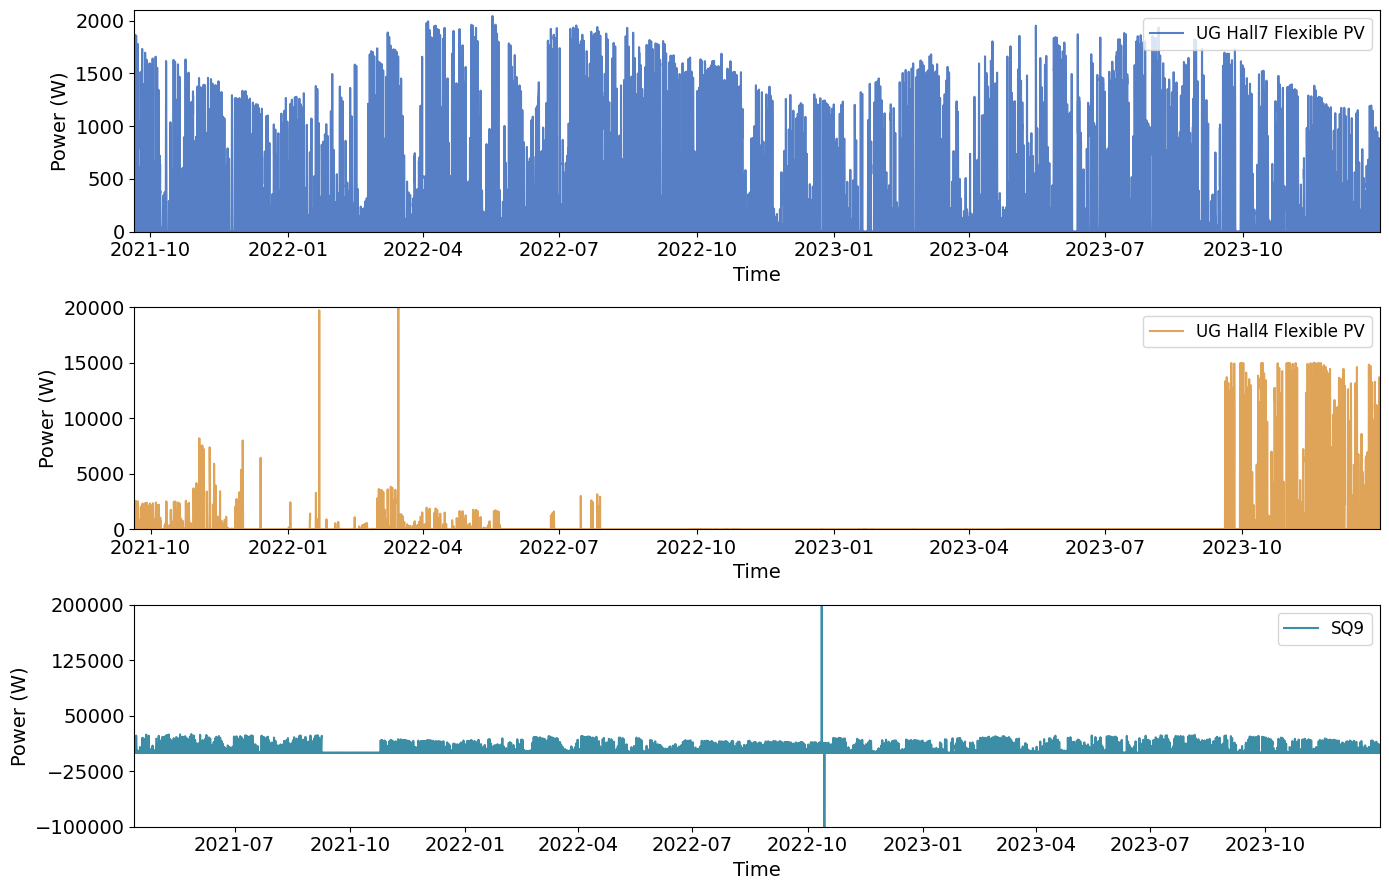

In [48]:
# Producing data plot for the report to show anomalies in the data and justify the cleansing steps taken

site_level_path = os.path.join(
    "Dataset", "Time series dataset", "PV generation dataset",
    "PV stations without panel level optimizer", "Site level dataset"
)

selected_sites = ["UG Hall7 Flexible PV", "UG Hall4 Flexible PV", "SQ9"]

fig, axes = plt.subplots(3, 1, figsize=(14, 9))

colour_map = {
    "UG Hall7 Flexible PV": "#2559B4C5",
    "UG Hall4 Flexible PV": "#E0A458",
    "SQ9": "#3B8EA5"
}

for i, site in enumerate(selected_sites):
    file_path = os.path.join(site_level_path, f"{site}.csv")
    df = pd.read_csv(file_path, index_col=0, parse_dates=True)
    axes[i].plot(df.index, df.iloc[:, 1], label=site, color=colour_map.get(site))  # second column: power(W)
    #axes[i].set_title(f"Power (W) for {site}")
    axes[i].set_xlabel("Time", fontsize = 14)
    axes[i].set_ylabel("Power (W)", fontsize = 14)
    axes[i].tick_params(axis='x', labelsize=14)
    axes[i].tick_params(axis='y', labelsize=14)

    if site == "UG Hall4 Flexible PV":
        axes[i].set_yticks(range(0, 20001, 5000))
    elif site == "SQ9":
        axes[i].set_yticks(range(-100000, 200001, 75000))
    else: 
        axes[i].set_yticks(range(0, 2001, 500))

    axes[i].legend(loc = 'upper right', fontsize = 12)

    if site == "UG Hall4 Flexible PV":
        axes[i].set_ylim(0, min(max(df.iloc[:, 1]), 20000)) 
    elif site == "SQ9":
        axes[i].set_ylim(-100000, min(max(df.iloc[:, 1]), 200000))
    else:
        axes[i].set_ylim(0,  2100)

    axes[i].set_xlim(df.index.min(), df.index.max())


plt.tight_layout()
plt.show()

## 2

Machine learning models used throughout the notebook

In [49]:
# Flexible RNN Model (Can be LSTM or GRU)
# For single cell prediction

class FlexibleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, rnn_type, dropout):
        super(FlexibleRNN, self).__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.rnn_type = rnn_type
        
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        else:
            self.rnn = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
            
        self.fc = nn.Linear(hidden_size, 1) # Sequence-to-One model for single step
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        if self.rnn_type == 'LSTM':
            c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
            out, _ = self.rnn(x, (h0, c0))
        else:
            out, _ = self.rnn(x, h0)
            
        out = self.fc(out[:, -1, :])
        return out

In [50]:
# Flexible RNN Model for Multi-Step Prediction (Can be LSTM or GRU)
# For single cell prediction but 24 hour

class FlexibleMultiStepRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, rnn_type, dropout):
        super(FlexibleMultiStepRNN, self).__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.rnn_type = rnn_type
        
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        else:
            self.rnn = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
            
        self.fc = nn.Linear(hidden_size, future_steps) # Sequence-to-vector model for multi-step
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        if self.rnn_type == 'LSTM':
            c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
            out, _ = self.rnn(x, (h0, c0))
        else:
            # GRU does not have a cell state (c0)
            out, _ = self.rnn(x, h0)
            
        out = self.fc(out[:, -1, :])
        return out

In [51]:
# Late Fusion model

class LateFusionModel(nn.Module):
    def __init__(self, dyn_input_size, stat_input_size, lstm_hidden, mlp_hidden, pred_length=96, rnn_type='GRU', dropout=0.2):
        super().__init__()
        
        # Dynamic Branch
        self.rnn = getattr(nn, rnn_type)(dyn_input_size, lstm_hidden, num_layers=2, batch_first=True, dropout=dropout)
        
        # Static Branch
        self.static_mlp = nn.Sequential(
            nn.Linear(stat_input_size, mlp_hidden),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # Fusion Head
        self.fusion_head = nn.Sequential(
            nn.Linear(lstm_hidden + mlp_hidden, 64),
            nn.ReLU(),
            nn.Linear(64, pred_length)
        )

    def forward(self, x_dyn, x_stat):
        rnn_out, _ = self.rnn(x_dyn)
        h_dyn = rnn_out[:, -1, :] 
        h_stat = self.static_mlp(x_stat)
        
        # Concatenate and predict
        combined = torch.cat((h_dyn, h_stat), dim=1)
        return self.fusion_head(combined)

In [ ]:
# FiLM model

class FiLMModel(nn.Module):
    def __init__(self, dyn_input_size, stat_input_size, lstm_hidden, pred_length = 96, rnn_type='GRU', dropout=0.2):
        super().__init__()
        
        # Dynamic Branch
        self.rnn = getattr(nn, rnn_type)(dyn_input_size, lstm_hidden, num_layers=2, batch_first=True, dropout=dropout)
        
        # FiLM Generator (Calculates Gamma and Beta from Static Data)
        self.film_generator = nn.Sequential(
            nn.Linear(stat_input_size, 32),
            nn.ReLU(),
            nn.Linear(32, lstm_hidden * 2) 
        )
        nn.init.zeros_(self.film_generator[-1].weight)
        nn.init.zeros_(self.film_generator[-1].bias)
        
        # Final Prediction Head
        self.prediction_head = nn.Linear(lstm_hidden, pred_length)

    def forward(self, x_dyn, x_stat):
        rnn_out, _ = self.rnn(x_dyn)
        h_dyn = rnn_out[:, -1, :]
        
        # Generate FiLM parameters
        film_params = self.film_generator(x_stat)

        gamma = film_params[:, :h_dyn.size(1)] + 1.0 
        beta = film_params[:, h_dyn.size(1):]
        
        # Apply the FiLM Affine Transformation
        modulated_h = (gamma * h_dyn) + beta

        return self.prediction_head(modulated_h)

## 3

Single cell prediction - 15 minuite time horizon for UG Hal 7

In [ ]:
# Load data for optuna

print("Loading data...")
df = merged_all.copy()
df.index = pd.to_datetime(df.index, format='mixed', dayfirst=True)

# Select features
features = [col for col in df.columns if col != 'generation(kWh)']
target_col = 'power(W)'
target_idx = features.index(target_col)

# Define training range
train_df = df.loc['2021-06-01':'2021-12-31']
test_df = df.loc['2022-01-01':'2022-03-31']
val_df = df.loc['2022-03-01':'2022-06-30']


# Scale
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df[features].values).astype(np.float32)
val_scaled = scaler.transform(val_df[features].values).astype(np.float32)
test_scaled = scaler.transform(test_df[features].values).astype(np.float32)

print('Done :)')

Loading data...
Done :)


In [ ]:
# Custom dataset maker for sequencing the data on the fly during optuna

class DynamicSequenceDataset(Dataset):
    def __init__(self, data, seq_length, target_idx, pred_length=1):
    
        self.data = data
        self.seq_length = seq_length
        self.target_idx = target_idx
        self.pred_length = pred_length

    def __len__(self):
        return len(self.data) - self.seq_length - self.pred_length + 1

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_length]
        start_y = idx + self.seq_length
        end_y = start_y + self.pred_length
        y = self.data[start_y : end_y, self.target_idx]
        return torch.tensor(x), torch.tensor(y)


In [ ]:
# Tune the model to find the best hyperparameters using the optuna function
# ---------------
# optimisation run time exceeds 24 hours, so the parameters which i tuned earlier are used instead
# If RUN_OPTUNA_SWEEP is set to True, it will run the sweep and reoptimise, a seed is used so the same parameters will be found 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
INPUT_SIZE = len(features)


# Can toggle on or off!
RUN_OPTUNA_SWEEP = False

if RUN_OPTUNA_SWEEP:
    print("Initiating Optuna Hyperparameter Sweep...")
    

    # use the bayesian estimator and harsh pruning mentioned in the report
    sampler = optuna.samplers.TPESampler(seed=42)
    study = optuna.create_study(direction="minimize", sampler=sampler, pruner=optuna.pruners.HyperbandPruner(min_resource=2, reduction_factor=3))

    # tune using the function from above
    study.optimize(lambda trial: objective(trial, model_name=FlexibleRNN), n_trials=50)
    
    print("\n--- OPTIMIZATION COMPLETE ---")
    print("Best Trial Value (MAE):", study.best_value)
    print("Best Parameters:")
    
    best_params = study.best_params
    print(json.dumps(best_params, indent=4))

    # Visualise parameter importances
    fig_importances = vis.plot_param_importances(study)
    fig_importances.show()

else:
    print("Skipping multi-hour Optuna sweep.")
    print("Loading pre-computed optimal hyperparameters to save compute time...")
    
    best_params ={
    "rnn_type": "GRU",
    "num_layers": 2,
    "hidden_size": 256,
    "dropout": 0.27198729329536875,
    "seq_length": 144,
    "lr": 0.003209631334457611,
    "loss_type": "Huber"
    }

print("\nActive Hyperparameters for Final Training:")
for key, value in best_params.items():
    print(f" - {key}: {value}")

Skipping multi-hour Optuna sweep.
Loading pre-computed optimal hyperparameters to save compute time...

Active Hyperparameters for Final Training:
 - rnn_type: GRU
 - num_layers: 2
 - hidden_size: 256
 - dropout: 0.27198729329536875
 - seq_length: 144
 - lr: 0.003209631334457611
 - loss_type: Huber


In [ ]:
# Calling dataloader function
train_loader, test_loader, val_loader, scaler, features, target_idx = create_dataloaders(
    df=merged_all,
    seq_length=best_params['seq_length'],
    batch_size=64
)

Starting training on cpu for up to 100 epochs...
Epoch [1/100] | Train Loss: 0.002925 | Test Loss: 0.036992
Epoch [2/100] | Train Loss: 0.001870 | Test Loss: 0.029318
Epoch [3/100] | Train Loss: 0.001846 | Test Loss: 0.031283
Epoch [4/100] | Train Loss: 0.001822 | Test Loss: 0.023871
Epoch [5/100] | Train Loss: 0.001813 | Test Loss: 0.030974
Epoch [6/100] | Train Loss: 0.001795 | Test Loss: 0.022055
Epoch [7/100] | Train Loss: 0.001799 | Test Loss: 0.029670
Epoch [8/100] | Train Loss: 0.001786 | Test Loss: 0.038187
Epoch [9/100] | Train Loss: 0.001785 | Test Loss: 0.030749
Epoch [10/100] | Train Loss: 0.001747 | Test Loss: 0.029574
Epoch [11/100] | Train Loss: 0.001740 | Test Loss: 0.033771
Early stopping triggered! No improvement for 5 epochs.
Restored best model weights (Test Loss: 0.022055)


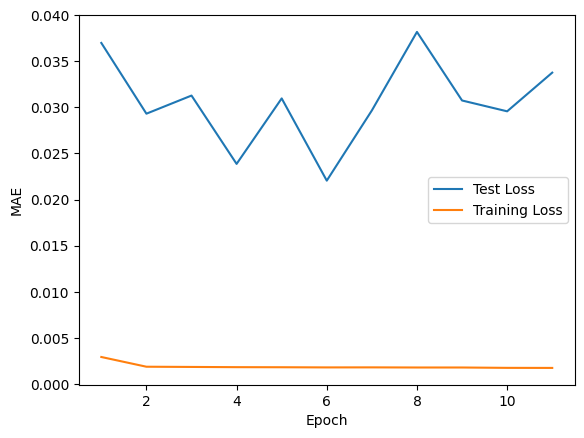

In [ ]:
input_size = len(features)

if best_params['loss_type'] == 'MSE':
    criterion = nn.MSELoss()
elif best_params['loss_type'] == 'L1loss':
    criterion = nn.L1Loss()
else:
    criterion = nn.HuberLoss()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_single_15 = FlexibleRNN(input_size, best_params['hidden_size'], best_params['num_layers'], best_params['rnn_type'], best_params['dropout']).to(device)
num_epochs = 100

# Using the best hyperparameters found, train the final model and plot the training and test loss curves
model_single_15, history = train_model(model = model_single_15, train_loader= train_loader, test_loader= test_loader, val_loader= val_loader, criterion= criterion, lr = best_params['lr'], epochs = num_epochs)

plt.plot(range(1, len(history['test_loss'])+1), history['test_loss'], label = 'Test Loss')
plt.plot(range(1, len(history['train_loss'])+1), history['train_loss'], label = 'Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()


Above:

Model and training
* Defines an RNN with LSTM - learn more detail about the architecture 
* trains the model and plots the losses


Average Validation MSE: 0.001992
Average Validation NMAE: 4.75%


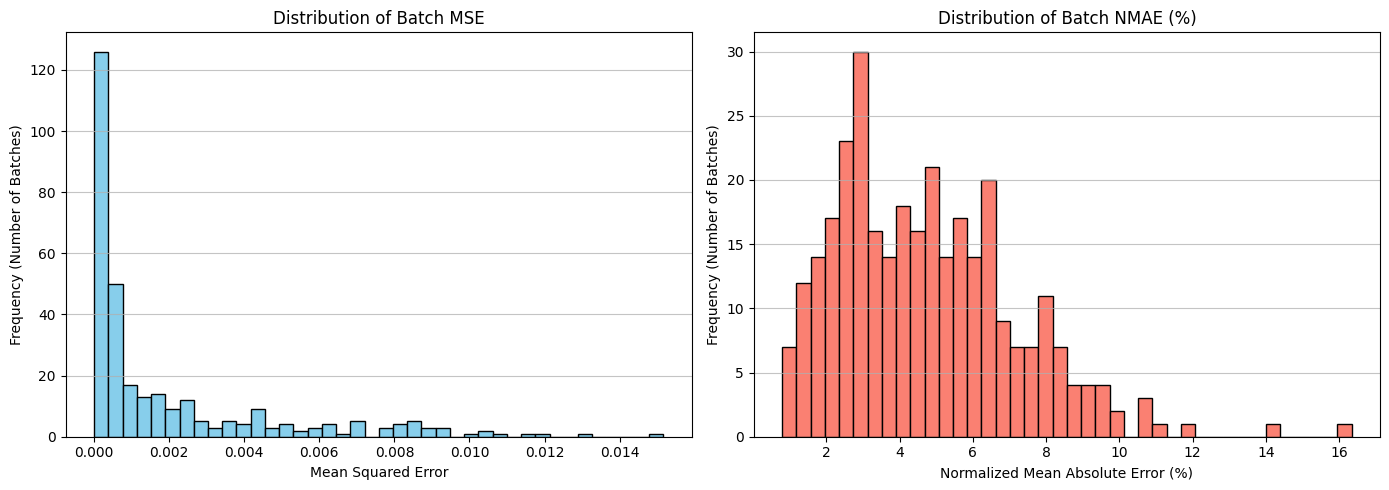

In [ ]:
# Analysis

model_single_15.eval()
val_mse_list = []
val_nmae_list = []

with torch.no_grad():
    for batch_idx, (inputs, targets) in enumerate(val_loader, start=1):
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model_single_15(inputs)

        # MSE in scaled space
        batch_mse = criterion(outputs, targets).item()
        val_mse_list.append(batch_mse)

        # NMAE in original power units (Watts)
        preds_batch = outputs.cpu().numpy().flatten()
        actuals_batch = targets.cpu().numpy().flatten()

        dummy_preds = np.zeros((len(preds_batch), len(features)))
        dummy_actuals = np.zeros((len(actuals_batch), len(features)))
        dummy_preds[:, target_idx] = preds_batch
        dummy_actuals[:, target_idx] = actuals_batch

        preds_unscaled = scaler.inverse_transform(dummy_preds)[:, target_idx]
        actuals_unscaled = scaler.inverse_transform(dummy_actuals)[:, target_idx]
        preds_unscaled = np.maximum(preds_unscaled, 0)

        batch_mae = np.mean(np.abs(actuals_unscaled - preds_unscaled))
        batch_peak = np.max(actuals_unscaled)

        if batch_peak > 0:
            batch_nmae = (batch_mae / batch_peak) * 100
        else:
            batch_nmae = np.nan

        val_nmae_list.append(batch_nmae)
        
        # ---> REMOVED the per-batch print statement here <---

# Calculate averages
avg_val_mse = float(np.nanmean(val_mse_list))
avg_val_nmae = float(np.nanmean(val_nmae_list))

# Print only the final averages
print(f"\nAverage Validation MSE: {avg_val_mse:.6f}")
print(f"Average Validation NMAE: {avg_val_nmae:.2f}%")

# ==========================================
# Plotting the Error Histograms
# ==========================================

# Filter out any NaN values from NMAE list so matplotlib doesn't complain
clean_nmae_list = [x for x in val_nmae_list if not np.isnan(x)]

# Create a figure with two subplots side-by-side
plt.figure(figsize=(14, 5))

# Plot 1: Histogram for MSE
plt.subplot(1, 2, 1)
plt.hist(val_mse_list, bins=40, color='skyblue', edgecolor='black')
plt.title('Distribution of Batch MSE')
plt.xlabel('Mean Squared Error')
plt.ylabel('Frequency (Number of Batches)')
plt.grid(axis='y', alpha=0.75)

# Plot 2: Histogram for NMAE
plt.subplot(1, 2, 2)
plt.hist(clean_nmae_list, bins=40, color='salmon', edgecolor='black')
plt.title('Distribution of Batch NMAE (%)')
plt.xlabel('Normalized Mean Absolute Error (%)')
plt.ylabel('Frequency (Number of Batches)')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

Above:

Tests the model on the validation data
* returns the MSE and NMAE for each batch aswell as the whole validation set
* 7.9% seems decent but hard to say for sure

going to need to adapt this - this is validating it on the 2023 data but its already seen it all 

Average Percentage Deviation (MAPE - Daylight hours only): 85.19%
Mean Absolute Error (MAE - All hours): 548.29 Watts
Normalised Mean Absolute Error (NMAE - All hours): 2.19


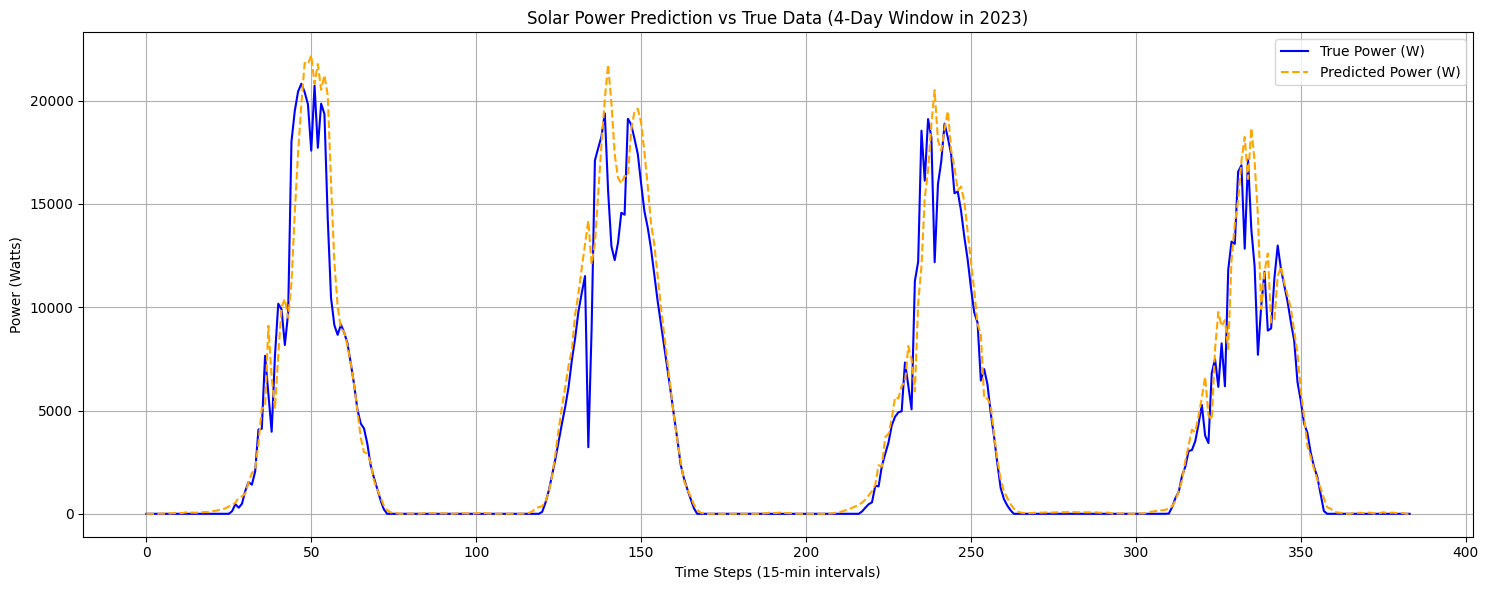

In [ ]:
# Plot as a few days - good visualisation - little misleading
# 1. Gather Predictions and Actuals from the 2023 Test Set
model_single_15.eval()
all_preds = []
all_actuals = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model_single_15(inputs)
        
        # Move back to CPU and convert to numpy
        all_preds.append(outputs.cpu().numpy())
        all_actuals.append(targets.cpu().numpy())

# Flatten lists
preds_array = np.concatenate(all_preds).flatten()
actuals_array = np.concatenate(all_actuals).flatten()

# 2. Inverse Transform to Original Scale (Watts)
# Create dummy arrays matching the exact number of features used during scaling
num_features = len(features)
dummy_preds = np.zeros((len(preds_array), num_features))
dummy_actuals = np.zeros((len(actuals_array), num_features))

# Place the predictions/actuals into the correct target column index
dummy_preds[:, target_idx] = preds_array
dummy_actuals[:, target_idx] = actuals_array

# Inverse transform and extract just the target column
preds_unscaled = scaler.inverse_transform(dummy_preds)[:, target_idx]
actuals_unscaled = scaler.inverse_transform(dummy_actuals)[:, target_idx]

# Ensure no negative predictions (solar power cannot physically be negative)
preds_unscaled = np.maximum(preds_unscaled, 0)

# 3. Calculate Validation Metrics
# Filter out nighttime / zero-power data to avoid Division by Zero
daylight_mask = actuals_unscaled > 1.0

if np.sum(daylight_mask) > 0:
    mape = np.mean(np.abs((actuals_unscaled[daylight_mask] - preds_unscaled[daylight_mask]) / actuals_unscaled[daylight_mask])) * 100
    print(f"Average Percentage Deviation (MAPE - Daylight hours only): {mape:.2f}%")
else:
    print("Not enough daylight data to calculate meaningful percentage deviation.")

mae = np.mean(np.abs(actuals_unscaled - preds_unscaled))
nmae = (mae / actuals_unscaled.max()) * 100
print(f"Mean Absolute Error (MAE - All hours): {mae:.2f} Watts")
print(f"Normalised Mean Absolute Error (NMAE - All hours): {nmae:.2f}")

# 4. Visualization (Plotting a 4-day window)
# 96 steps per day. Let's start at index 96 * 100 (approx 100 days into 2023, mid-April) 
# to see some good spring/summer generation curves.
START_IDX = 96 * 100
PLOT_WINDOW = 96 * 4  # 4 days

# Safely handle if the test set is shorter than expected
if START_IDX + PLOT_WINDOW > len(actuals_unscaled):
    START_IDX = 0

plt.figure(figsize=(15, 6))
plt.plot(actuals_unscaled[START_IDX : START_IDX + PLOT_WINDOW], label='True Power (W)', color='blue', linewidth=1.5)
plt.plot(preds_unscaled[START_IDX : START_IDX + PLOT_WINDOW], label='Predicted Power (W)', color='orange', linestyle='--', linewidth=1.5)

plt.title('Solar Power Prediction vs True Data (4-Day Window in 2023)')
plt.xlabel('Time Steps (15-min intervals)')
plt.ylabel('Power (Watts)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Above:

I believe this just applies the model to a significant chunk of data and then visualises it

visualisation plot is a little misleading as the model is only acutally predicting the next 15 minuite interval

I think this experiences data leakage from the training and visualisation above. check it hasnt already seen this validation data.

Good NMAE, worryingly though its a lot better than higher up, data leakage? 

In [ ]:

residuals = actuals_unscaled - preds_unscaled

np.shape(residuals)

(14493,)

ValueError: x and y must be the same size

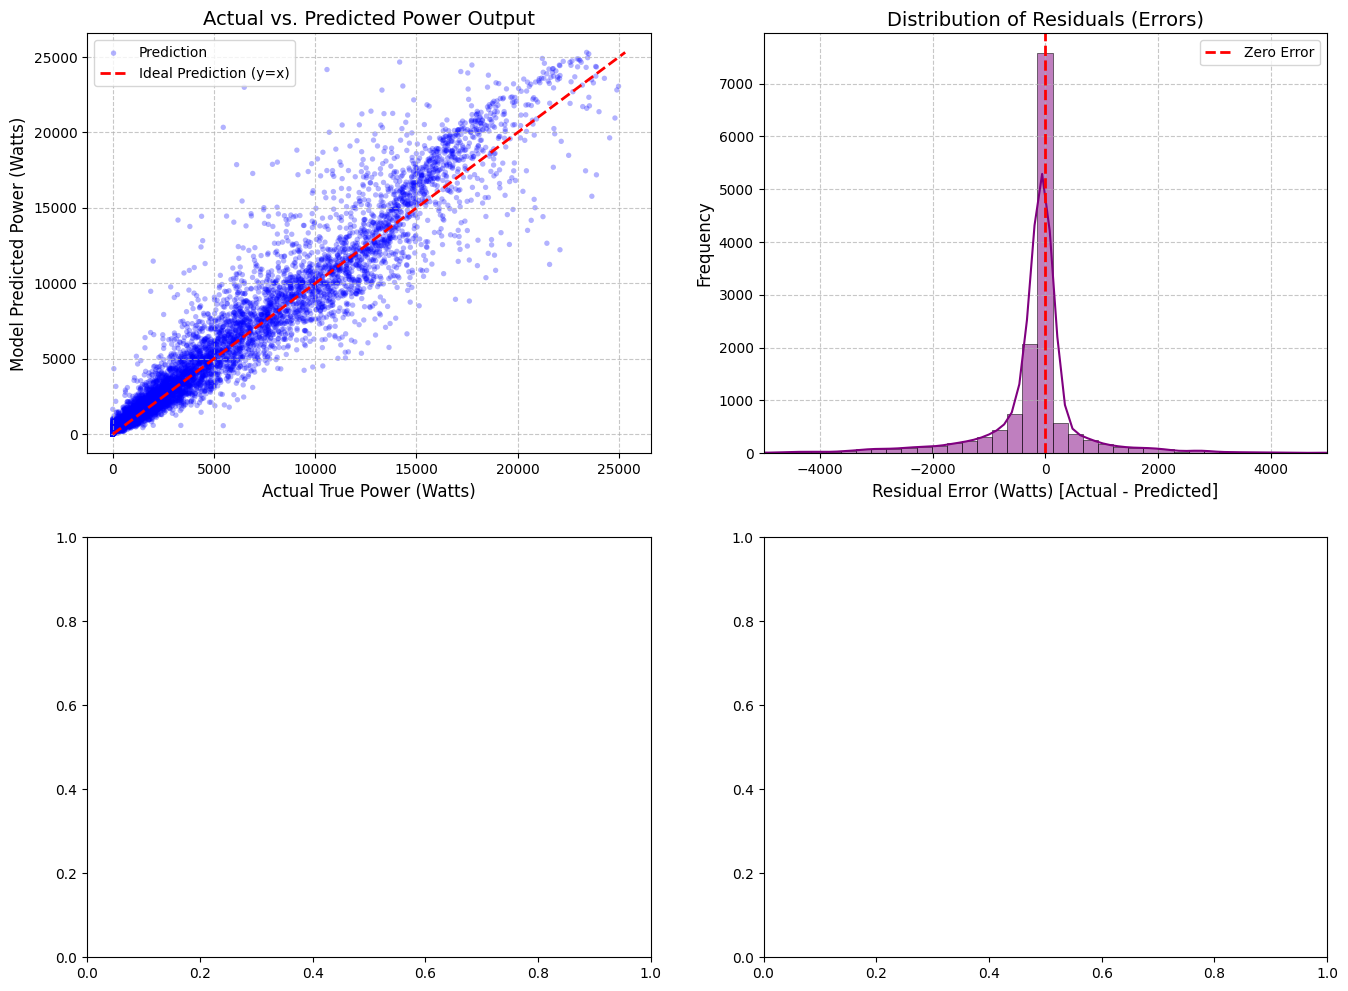

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Residuals
residuals = actuals_unscaled - preds_unscaled

# Set up the figure for three plots (2 on top, 1 on bottom)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# --- Plot 1: Actual vs. Predicted Scatter Plot ---
axes[0].scatter(actuals_unscaled, preds_unscaled, alpha=0.3, color='blue', edgecolor='none', s=15, label = 'Prediction')

# Plot the "Perfect Accuracy" line (y = x)
max_val = max(np.max(actuals_unscaled), np.max(preds_unscaled))
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Ideal Prediction (y=x)')

axes[0].set_title('Actual vs. Predicted Power Output', fontsize=14)
axes[0].set_xlabel('Actual True Power (Watts)', fontsize=12)
axes[0].set_ylabel('Model Predicted Power (Watts)', fontsize=12)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# --- Plot 2: Residuals Distribution Histogram ---
sns.histplot(residuals, bins=100, kde=True, ax=axes[1], color='purple', edgecolor='black')

axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].set_title('Distribution of Residuals (Errors)', fontsize=14)
axes[1].set_xlabel('Residual Error (Watts) [Actual - Predicted]', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_xlim(-5000, 5000)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

# --- Plot 3: Residuals vs Time of Day ---
axes[2].scatter(Time_Sin, residuals, alpha=0.3, color='green', edgecolor='none', s=15)
axes[2].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[2].set_title('Residuals vs Time of Day', fontsize=14)
axes[2].set_xlabel('Time of Day (Hours)', fontsize=12)
axes[2].set_ylabel('Residual Error (Watts)', fontsize=12)
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.7)

# Hide the 4th subplot
axes[3].set_visible(False)

plt.suptitle('Final Model: Residual Analysis and Systematic Bias Check', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Next - model optimisation and LSTM v GRU testing

Want to test LSTM v GRU to prove which is best

For each I want to optimise all the hyperparameters:
* hidden size
* layers
* learning rate
* weight decay?
* optimiser?
* sequence length

going to use optuna and create a variable dataloader

## 4

single cell prediction - 24 hours time horizon for UG Hall7


In [ ]:
# How many 15 min intervals to predict forwards
future_steps = 96


In [ ]:
# Tune the model to find the best hyperparameters using the optuna function
# ---------------
# optimisation run time exceeds 24 hours, so the parameters which i tuned earlier are used instead
# If RUN_OPTUNA_SWEEP is set to True, it will run the sweep and reoptimise, a seed is used so the same parameters will be found 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_size = len(features)


RUN_OPTUNA_SWEEP = False

if RUN_OPTUNA_SWEEP:
    print("Initiating Optuna Hyperparameter Sweep...")
    
   # use the bayesian estimator and harsh pruning mentioned in the report
    sampler = optuna.samplers.TPESampler(seed=42)
    study = optuna.create_study(direction="minimize", sampler=sampler, pruner=optuna.pruners.HyperbandPruner(min_resource=2, reduction_factor=3))

    # tune using the function from above
    study.optimize(lambda trial: objective(trial, model_name=FlexibleMultiStepRNN, pred_length=future_steps), n_trials=50)
    
    print("\n--- OPTIMIZATION COMPLETE ---")
    print("Best Trial Value (MAE):", study.best_value)
    print("Best Parameters:")
    
    best_params = study.best_params
    print(json.dumps(best_params, indent=4))

    # visualise parameter importances
    fig_importances = vis.plot_param_importances(study)
    fig_importances.show()

else:
    print("Skipping multi-hour Optuna sweep.")
    print("Loading pre-computed optimal hyperparameters to save compute time...")
    
    best_params = {
        "rnn_type": "GRU",
        "num_layers": 2,
        "hidden_size": 64,
        "dropout": 0.3426703424320757,
        "seq_length": 384,
        "lr": 0.007256500262882687,
        "loss_type": "MAE"
    }


Skipping multi-hour Optuna sweep.
Loading pre-computed optimal hyperparameters to save compute time...


In [ ]:
# Calling dataloader function
train_loader, test_loader, val_loader, scaler, features, target_idx = create_dataloaders(
    df=merged_all,
    seq_length=best_params['seq_length'],
    pred_length = future_steps,
    batch_size=64
)

Starting training on cpu for up to 100 epochs...
Epoch [1/100] | Train Loss: 0.006587 | Test Loss: 0.067729
Epoch [2/100] | Train Loss: 0.005017 | Test Loss: 0.062361
Epoch [3/100] | Train Loss: 0.005949 | Test Loss: 0.075965
Epoch [4/100] | Train Loss: 0.005977 | Test Loss: 0.059464
Epoch [5/100] | Train Loss: 0.005682 | Test Loss: 0.071091
Epoch [6/100] | Train Loss: 0.005116 | Test Loss: 0.070390
Epoch [7/100] | Train Loss: 0.003858 | Test Loss: 0.064487
Epoch [8/100] | Train Loss: 0.003323 | Test Loss: 0.065017
Epoch [9/100] | Train Loss: 0.002918 | Test Loss: 0.063729
Early stopping triggered! No improvement for 5 epochs.
Restored best model weights (Test Loss: 0.059464)


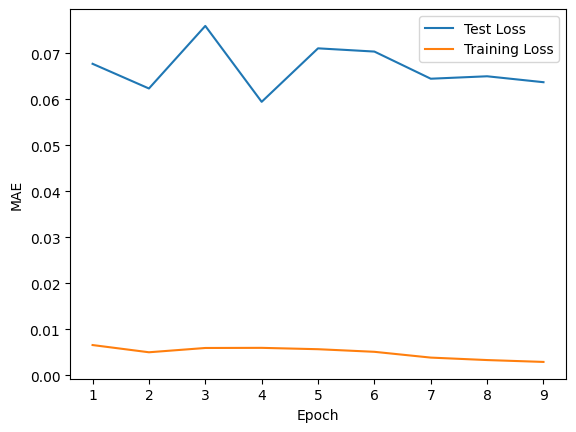

In [ ]:
input_size = len(features)

if best_params['num_layers'] == 1:
    dropout = 0
else:
    dropout = best_params['dropout']

if best_params['loss_type'] == 'MSE':
    criterion = nn.MSELoss()
elif best_params['loss_type'] == 'L1loss':
    criterion = nn.L1Loss()
else:
    criterion = nn.HuberLoss()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_single_24 = FlexibleMultiStepRNN(input_size, best_params['hidden_size'], best_params['num_layers'], best_params['rnn_type'], dropout).to(device)
num_epochs = 100

# Using the best hyperparameters found, train the final model and plot the training and test loss curves
model_single_24, history = train_model(model = model_single_24, train_loader= train_loader, test_loader= test_loader, val_loader= val_loader, criterion= criterion, lr = best_params['lr'], epochs = num_epochs)

plt.plot(range(1, len(history['test_loss'])+1), history['test_loss'], label = 'Test Loss')
plt.plot(range(1, len(history['train_loss'])+1), history['train_loss'], label = 'Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()



Average Validation MSE: 0.005343
Average Validation NMAE: 9.81%


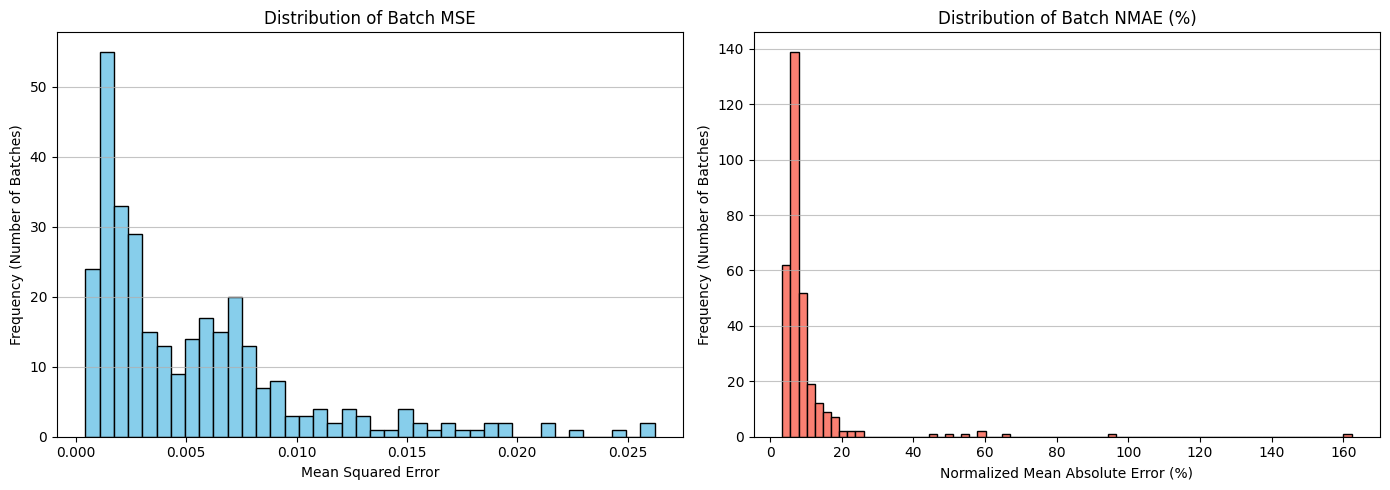

In [ ]:
model_single_24.eval()
val_mse_list = []
val_nmae_list = []


num_features = len(features) 

with torch.no_grad():
    for batch_idx, (inputs, targets) in enumerate(val_loader, start=1):
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model_single_24(inputs)

        # MSE in scaled space
        batch_mse = criterion(outputs, targets).item()
        val_mse_list.append(batch_mse)

        # NMAE in original power units (Watts)
        preds_batch = outputs.cpu().numpy().flatten()
        actuals_batch = targets.cpu().numpy().flatten()

        preds_unscaled, actuals_unscaled = unscale_power_values(preds=preds_batch, actuals=actuals_batch, scaler=scaler, target_idx=target_idx, num_features=num_features)

        batch_mae = np.mean(np.abs(actuals_unscaled - preds_unscaled))
        batch_peak = np.max(actuals_unscaled)

        if batch_peak > 0:
            batch_nmae = (batch_mae / batch_peak) * 100
        else:
            batch_nmae = np.nan

        val_nmae_list.append(batch_nmae)
        
# Calculate averages
avg_val_mse = float(np.nanmean(val_mse_list))
avg_val_nmae = float(np.nanmean(val_nmae_list))
print(f"\nAverage Validation MSE: {avg_val_mse:.6f}")
print(f"Average Validation NMAE: {avg_val_nmae:.2f}%")



# Plotting the error histograms

clean_nmae_list = [x for x in val_nmae_list if not np.isnan(x)]

plt.figure(figsize=(14, 5))

# Plot 1: Histogram for MSE
plt.subplot(1, 2, 1)
plt.hist(val_mse_list, bins=40, color='skyblue', edgecolor='black')
plt.title('Distribution of Batch MSE')
plt.xlabel('Mean Squared Error')
plt.ylabel('Frequency (Number of Batches)')
plt.grid(axis='y', alpha=0.75)

# Plot 2: Histogram for NMAE
plt.subplot(1, 2, 2)
plt.hist(clean_nmae_list, bins=70, color='salmon', edgecolor='black')
plt.title('Distribution of Batch NMAE (%)')
plt.xlabel('Normalized Mean Absolute Error (%)')
plt.ylabel('Frequency (Number of Batches)')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

Average Percentage Deviation (MAPE - Daylight hours only): 360.01%
Mean Absolute Error (MAE - All hours): 1363.22 Watts
Normalised Mean Absolute Error (NMAE - All hours): 5.46%


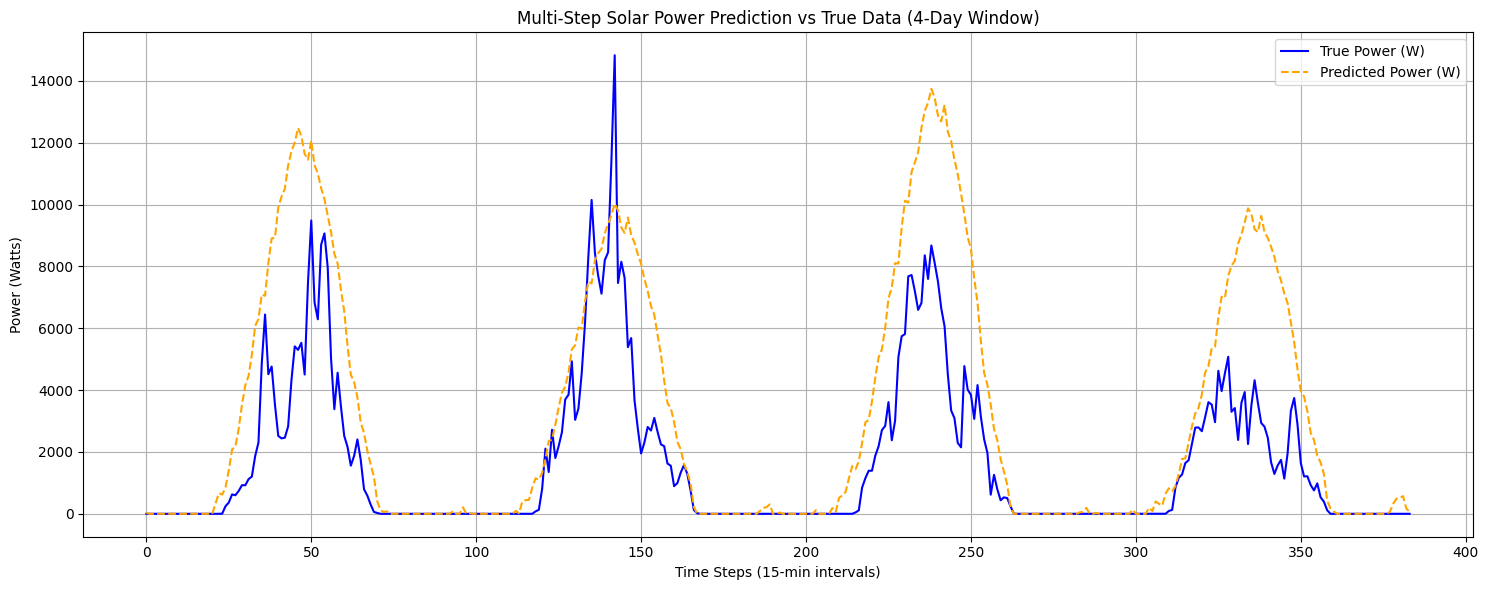

In [ ]:
# Define your prediction length (24 hours * 4 steps/hour = 96)
PRED_LENGTH = 96 

model_single_24.eval()
all_preds = []
all_actuals = []

# 1. Gather all predictions from the test set
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        all_preds.append(model_single_24(inputs).cpu().numpy())
        all_actuals.append(targets.cpu().numpy())

# Flatten and slice to create non-overlapping continuous data
preds_array = np.concatenate(all_preds)[::PRED_LENGTH].flatten()
actuals_array = np.concatenate(all_actuals)[::PRED_LENGTH].flatten()

# 2. Unscale using the helper function (Removes the redundant code block)
num_features = len(features)
preds_unscaled, actuals_unscaled = unscale_power_values(
    preds=preds_array, 
    actuals=actuals_array, 
    scaler=scaler, 
    target_idx=target_idx, 
    num_features=num_features
)

# 3. Calculate Validation Metrics 
daylight_mask = actuals_unscaled > 1.0

if np.sum(daylight_mask) > 0:
    mape = np.mean(np.abs((actuals_unscaled[daylight_mask] - preds_unscaled[daylight_mask]) / actuals_unscaled[daylight_mask])) * 100
    print(f"Average Percentage Deviation (MAPE - Daylight hours only): {mape:.2f}%")
else:
    print("Not enough daylight data to calculate meaningful percentage deviation.")

mae = np.mean(np.abs(actuals_unscaled - preds_unscaled))
nmae = (mae / actuals_unscaled.max()) * 100
print(f"Mean Absolute Error (MAE - All hours): {mae:.2f} Watts")
print(f"Normalised Mean Absolute Error (NMAE - All hours): {nmae:.2f}%")

# 4. Visualization (Plotting a 4-day window)
START_IDX = 96 * 130
PLOT_WINDOW = 96 * 4  # 4 days

# Safely handle if the non-overlapping test set is shorter than expected
if START_IDX + PLOT_WINDOW > len(actuals_unscaled):
    START_IDX = 0

plt.figure(figsize=(15, 6))
plt.plot(actuals_unscaled[START_IDX : START_IDX + PLOT_WINDOW], label='True Power (W)', color='blue', linewidth=1.5)
plt.plot(preds_unscaled[START_IDX : START_IDX + PLOT_WINDOW], label='Predicted Power (W)', color='orange', linestyle='--', linewidth=1.5)

plt.title('Multi-Step Solar Power Prediction vs True Data (4-Day Window)')
plt.xlabel('Time Steps (15-min intervals)')
plt.ylabel('Power (Watts)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# calculate residuals
residuals = preds_unscaled - actuals_unscaled


time_sin_idx = features.index('Time_Sin')

all_time_sin = []
model_single_24.eval()
with torch.no_grad():
    for inputs, targets in test_loader:
        last_step_time_sin = inputs[:, -1, time_sin_idx].cpu().numpy()
        all_time_sin.append(last_step_time_sin)


time_sin_array = np.concatenate(all_time_sin)[::PRED_LENGTH].flatten()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


# Plot 1: Actual vs Predicted Scatter
axes.scatter(actuals_unscaled, preds_unscaled, alpha=0.3, color='dodgerblue', edgecolor='k', linewidth=0.5)
min_val = min(actuals_unscaled.min(), preds_unscaled.min())
max_val = max(actuals_unscaled.max(), preds_unscaled.max())

axes.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='y = x (Perfect Fit)')
axes.set_title('Actual vs Predicted Power')
axes.set_xlabel('Actual Power (W)')
axes.set_ylabel('Predicted Power (W)')
axes.legend()
axes.grid(True, alpha=0.3)


# Plot 2: Histogram of Residuals
axes.hist(residuals, bins=50, color='mediumorchid', edgecolor='black', alpha=0.7)
axes.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes.set_title('Distribution of Residuals')
axes.set_xlabel('Residual (Predicted - Actual) [W]')
axes.set_ylabel('Frequency')
axes.legend()
axes.grid(True, axis='y', alpha=0.3)


# Plot 3: Residuals vs Time_Sin
axes.scatter(time_sin_array, residuals, alpha=0.3, color='mediumseagreen', edgecolor='k', linewidth=0.5)
axes.axhline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes.set_title('Residuals vs Time of Day (Time_Sin)')
axes.set_xlabel('Time_Sin cyclical encoding')
axes.set_ylabel('Residual (Predicted - Actual) [W]')
axes.legend()
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5

Multi cell prediction - 24 hour time horizon


In [ ]:
# transforming data for multi cell prediction model

'''
Initially built with help from Gemini - heavily adapted afterwards
'''

# Separate features
target_col = 'power(W)' 
static_cols = ['Has_Optimizer', 'Total_Capacity_W', 'Efficiency']

# 1. Force pandas to only look at numeric columns (floats and ints)
numeric_columns = clean_mega_dataset.select_dtypes(include=['number']).columns

# 2. Build dynamic_cols strictly from those numeric columns
dynamic_cols = [c for c in numeric_columns if c not in static_cols + [target_col]]


# 1. Define the exact Site IDs you want to hold out for testing. 
# (Replace these strings with actual names from your mega_dataset['Site_ID'])
holdout_sites = ['Zone A4', 'SQ Block R', 'UG Hall7 Flexible PV'] 

# 2. Create the masks
# Test set: ONLY the 3 holdout sites (we can give them their entire timeline to test on)
val_mask = clean_mega_dataset['Site_ID'].isin(holdout_sites)

# Train & Val sets: ONLY the remaining sites, split chronologically
train_mask = (~val_mask) & (clean_mega_dataset.index >= '2022-01-01') & (clean_mega_dataset.index <= '2022-06-30')
test_mask = (~val_mask) & (clean_mega_dataset.index >= '2022-07-01') & (clean_mega_dataset.index <= '2022-08-31')

val_mask = val_mask & (clean_mega_dataset.index >= '2022-01-01') & (clean_mega_dataset.index <= '2022-06-30')

# 3. Create the DataFrames
train_df = clean_mega_dataset.loc[train_mask].copy()
val_df = clean_mega_dataset.loc[val_mask].copy()
test_df = clean_mega_dataset.loc[test_mask].copy()

# 4. FIT SCALERS ON TRAIN ONLY (Crucial for Spatial Generalization)
dyn_scaler = StandardScaler().fit(train_df[dynamic_cols])
stat_scaler = StandardScaler().fit(train_df[static_cols])
target_scaler = StandardScaler().fit(train_df[[target_col]])

# 5. TRANSFORM ALL
for df in [train_df, val_df, test_df]:
    df[dynamic_cols] = dyn_scaler.transform(df[dynamic_cols])
    df[static_cols] = stat_scaler.transform(df[static_cols])
    df[[target_col]] = target_scaler.transform(df[[target_col]])

print(train_df.shape, val_df.shape, test_df.shape)

(527876, 18) (38679, 18) (186565, 18)


In [62]:
future_steps = 96

class PVTimeSeriesDataset(Dataset):
    def __init__(self, dataframe, dynamic_features, static_features, target, sequence_length, pred_length):
        self.seq_len = sequence_length
        self.pred_len = pred_length
        
        # 1. Reset index
        df_clean = dataframe.reset_index()
        
        # 2. Sort by Site_ID and Time
        df_clean = df_clean.sort_values(by=['Site_ID', 'Time'])
        
        # 3. Extract numpy arrays
        self.dynamic_data = df_clean[dynamic_features].values
        self.static_data = df_clean[static_features].values
        self.target_data = df_clean[[target]].values
        
        # NEW: Extract the raw Time array to check for gaps
        self.time_data = df_clean['Time'].values 
        
        self.valid_indices = []
        site_groups = df_clean.groupby('Site_ID', sort=False)

        step_size = 50
        
        for _, group in site_groups:
            group_len = len(group)
            row_indices = group.index.values 
            
            if group_len > self.seq_len + self.pred_len - 1:
                # ADD THE STEP SIZE HERE
                for i in range(0, group_len - self.seq_len - self.pred_len + 1, step_size):
                    abs_start_idx = row_indices[i]
                    abs_end_idx = row_indices[i + self.seq_len + self.pred_len - 1] 
                    
                    time_start = self.time_data[abs_start_idx]
                    time_end = self.time_data[abs_end_idx]
                    
                    expected_diff = np.timedelta64((self.seq_len + self.pred_len - 1) * 15, 'm')
                    if (time_end - time_start) == expected_diff:
                        self.valid_indices.append(abs_start_idx)

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        start = self.valid_indices[idx]
        seq_end = start + self.seq_len
        target_idx = seq_end + self.pred_len - 1 
        
        x_dyn = torch.tensor(self.dynamic_data[start:seq_end], dtype=torch.float32)
        x_stat = torch.tensor(self.static_data[seq_end], dtype=torch.float32)
        
        # Optionally, you can return a sequence of targets by doing [seq_end : seq_end + self.pred_len]
        y = torch.tensor(self.target_data[seq_end : seq_end + self.pred_len].flatten(), dtype=torch.float32)
        
        return x_dyn, x_stat, y


In [56]:
dyn_size = len(dynamic_cols)
stat_size = len(static_cols)

In [ ]:
# Tune the model to find the best hyperparameters using the optuna function
# ---------------
# optimisation run time exceeds 24 hours, so the parameters which i tuned earlier are used instead
# If RUN_OPTUNA_SWEEP is set to True, it will run the sweep and reoptimise, a seed is used so the same parameters will be found 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Can toggle on or off
RUN_OPTUNA_SWEEP = True

if RUN_OPTUNA_SWEEP:
    print("Initiating Optuna Hyperparameter Sweep...")
    
    # use the bayesian estimator and harsh pruning mentioned in the report
    sampler = optuna.samplers.TPESampler(seed=42)
    study = optuna.create_study(direction="minimize", sampler=sampler, pruner=optuna.pruners.HyperbandPruner(min_resource=2, reduction_factor=3))

    # tune using the function from above
    study.optimize(lambda trial: objective(trial, model_name = None, pred_length=future_steps, fusion_mode = True), n_trials=20)
    
    print("\n--- OPTIMIZATION COMPLETE ---")
    print("Best Trial Value (MAE):", study.best_value)
    print("Best Parameters:")
    
    best_params = study.best_params
    print(json.dumps(best_params, indent=4))

    fig_importances = vis.plot_param_importances(study)
    fig_importances.show()

else:
    print("Skipping multi-hour Optuna sweep.")
    print("Loading pre-computed optimal hyperparameters to save compute time...")
    
    best_params = {
        "rnn_type": "LSTM",
        "num_layers": 1,
        "hidden_size": 64,
        "seq_length": 24,
        "lr": 0.006097025297491433,
        "loss_type": "Huber",
        "fusion_type": "LateFusion",
        "lstm_hidden": 256,
        "mlp_hidden": 16
    }


[I 2026-04-22 14:45:13,116] A new study created in memory with name: no-name-7d55bd34-cec9-4d04-8cb4-4356f2ce88aa


Initiating Optuna Hyperparameter Sweep...


[I 2026-04-22 14:46:54,682] Trial 0 finished with value: 0.4061138078018471 and parameters: {'rnn_type': 'LSTM', 'num_layers': 2, 'hidden_size': 32, 'dropout': 0.11742508365045984, 'seq_length': 192, 'lr': 0.00026587543983272726, 'loss_type': 'Huber', 'fusion_type': 'LateFusion', 'lstm_hidden': 64, 'mlp_hidden': 32}. Best is trial 0 with value: 0.4061138078018471.
[I 2026-04-22 14:47:10,214] Trial 1 finished with value: 0.3419155509660775 and parameters: {'rnn_type': 'LSTM', 'num_layers': 1, 'hidden_size': 32, 'seq_length': 48, 'lr': 0.0007591104805282694, 'loss_type': 'MAE', 'fusion_type': 'LateFusion', 'lstm_hidden': 32, 'mlp_hidden': 16}. Best is trial 1 with value: 0.3419155509660775.
[I 2026-04-22 14:47:47,915] Trial 2 pruned. 
[I 2026-04-22 14:51:26,277] Trial 3 finished with value: 0.21121132112701854 and parameters: {'rnn_type': 'GRU', 'num_layers': 1, 'hidden_size': 128, 'seq_length': 96, 'lr': 0.0033233042062267943, 'loss_type': 'MAE', 'fusion_type': 'LateFusion', 'lstm_hidde

In [ ]:
# transforming data for multi cell prediction model

'''
Initially built with help from Gemini - heavily adapted afterwards
'''

# Separate features
target_col = 'power(W)' 
static_cols = ['Has_Optimizer', 'Total_Capacity_W', 'Efficiency']

# 1. Force pandas to only look at numeric columns (floats and ints)
numeric_columns = clean_mega_dataset.select_dtypes(include=['number']).columns

# 2. Build dynamic_cols strictly from those numeric columns
dynamic_cols = [c for c in numeric_columns if c not in static_cols + [target_col]]


# 1. Define the exact Site IDs you want to hold out for testing. 
# (Replace these strings with actual names from your mega_dataset['Site_ID'])
holdout_sites = ['Zone A4', 'SQ Block R', 'UG Hall7 Flexible PV'] 

# 2. Create the masks
# Test set: ONLY the 3 holdout sites (we can give them their entire timeline to test on)
val_mask = clean_mega_dataset['Site_ID'].isin(holdout_sites)

# Train & Val sets
# only the remaining sites
# take a longer training window than for optimisation 
train_mask = (~val_mask) & (clean_mega_dataset.index >= '2021-01-01') & (clean_mega_dataset.index <= '2022-06-30')
test_mask = (~val_mask) & (clean_mega_dataset.index >= '2022-07-01') & (clean_mega_dataset.index <= '2022-08-31')

# 3. Create the DataFrames
train_df = clean_mega_dataset.loc[train_mask].copy()
val_df = clean_mega_dataset.loc[val_mask].copy()
test_df = clean_mega_dataset.loc[test_mask].copy()

# 4. FIT SCALERS ON TRAIN ONLY (Crucial for Spatial Generalization)
dyn_scaler = StandardScaler().fit(train_df[dynamic_cols])
stat_scaler = StandardScaler().fit(train_df[static_cols])
target_scaler = StandardScaler().fit(train_df[[target_col]])

# 5. TRANSFORM ALL
for df in [train_df, val_df, test_df]:
    df[dynamic_cols] = dyn_scaler.transform(df[dynamic_cols])
    df[static_cols] = stat_scaler.transform(df[static_cols])
    df[[target_col]] = target_scaler.transform(df[[target_col]])

print(train_df.shape, val_df.shape, test_df.shape)


train_dataset = PVTimeSeriesDataset(train_df, dynamic_cols, static_cols, target_col, sequence_length=seq_length, pred_length=pred_length)
test_dataset = PVTimeSeriesDataset(test_df, dynamic_cols, static_cols, target_col, sequence_length=seq_length, pred_length=pred_length)
val_dataset = PVTimeSeriesDataset(val_df, dynamic_cols, static_cols, target_col, sequence_length=seq_length, pred_length=pred_length)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
    



KeyboardInterrupt: 

Starting training on cpu for up to 20 epochs...
Epoch [1/20] | Train Loss: 2184.377890 | Test Loss: 1440.728819
Epoch [2/20] | Train Loss: 1282.240650 | Test Loss: 885.598160
Epoch [3/20] | Train Loss: 963.969222 | Test Loss: 681.325445
Epoch [4/20] | Train Loss: 907.679109 | Test Loss: 581.602201
Epoch [5/20] | Train Loss: 877.122270 | Test Loss: 562.035094
Epoch [6/20] | Train Loss: 856.365103 | Test Loss: 546.346166
Epoch [7/20] | Train Loss: 833.830895 | Test Loss: 537.142559
Epoch [8/20] | Train Loss: 818.881181 | Test Loss: 520.790276
Epoch [9/20] | Train Loss: 804.672484 | Test Loss: 453.201434
Epoch [10/20] | Train Loss: 808.928752 | Test Loss: 474.160251
Epoch [11/20] | Train Loss: 809.052689 | Test Loss: 453.241769
Epoch [12/20] | Train Loss: 858.461778 | Test Loss: 620.109423
Epoch [13/20] | Train Loss: 827.900252 | Test Loss: 559.157350
Epoch [14/20] | Train Loss: 833.934610 | Test Loss: 492.883342
Early stopping triggered! No improvement for 5 epochs.
Restored best model w

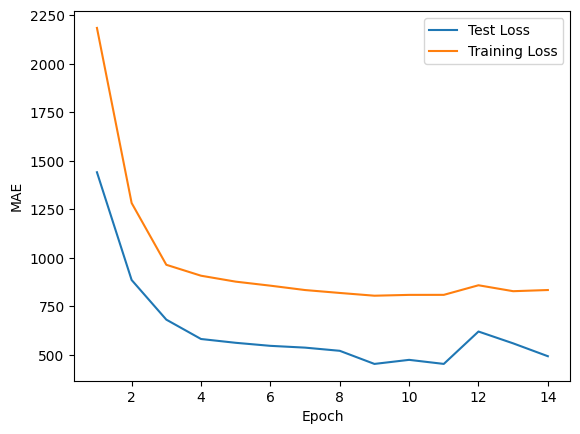

In [ ]:
input_size = len(features)

if best_params['num_layers'] == 1:
    dropout = 0
else:
    dropout = best_params['dropout']

if best_params['loss_type'] == 'MSE':
    criterion = nn.MSELoss()
elif best_params['loss_type'] == 'L1loss':
    criterion = nn.L1Loss()
else:
    criterion = nn.HuberLoss()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Use the method which was found to be optimal
if best_params['fusion_type'] == 'FiLM':
   model_multi = FiLMModel(
        dyn_input_size=dyn_size, 
        stat_input_size=stat_size, 
        lstm_hidden=best_params['hidden_size'], 
        rnn_type=best_params['rnn_type'], 
        dropout=dropout).to(device)
else:
    model_multi = LateFusionModel(
        dyn_input_size=dyn_size, 
        stat_input_size=stat_size, 
        lstm_hidden=best_params['hidden_size'], 
        mlp_hidden=best_params['mlp_hidden'],
        rnn_type=best_params['rnn_type'], 
        dropout=dropout).to(device)



num_epochs = 20

# using the best hyperparameters found, train the final model and plot the training and test loss curves
model_multi, history = train_model(model = model_multi, train_loader= train_loader, test_loader= test_loader, val_loader= val_loader, fusion_mode=True, criterion= criterion, lr = best_params['lr'], epochs = num_epochs)

plt.plot(range(1, len(history['test_loss'])+1), history['test_loss'], label = 'Test Loss')
plt.plot(range(1, len(history['train_loss'])+1), history['train_loss'], label = 'Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()



Average Validation MSE: 500.391251
Average Validation NMAE: 4.01%


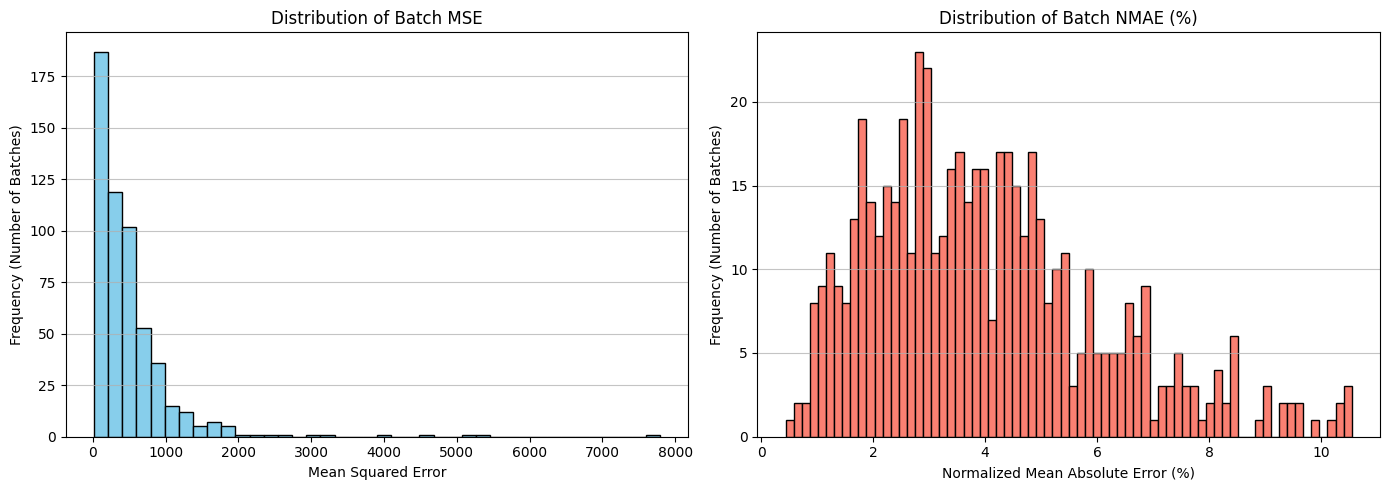

In [ ]:
model_multi.eval()
val_mse_list = []
val_nmae_list = []


num_features = len(features) 

with torch.no_grad():
    for batch_idx, (inputs, targets) in enumerate(val_loader, start=1):
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model_multi(inputs)

        # MSE in scaled space
        batch_mse = criterion(outputs, targets).item()
        val_mse_list.append(batch_mse)

        # NMAE in original power units (Watts)
        preds_batch = outputs.cpu().numpy().flatten()
        actuals_batch = targets.cpu().numpy().flatten()

        preds_unscaled, actuals_unscaled = unscale_power_values(preds=preds_batch, actuals=actuals_batch, scaler=scaler, target_idx=target_idx, num_features=num_features)

        batch_mae = np.mean(np.abs(actuals_unscaled - preds_unscaled))
        batch_peak = np.max(actuals_unscaled)

        if batch_peak > 0:
            batch_nmae = (batch_mae / batch_peak) * 100
        else:
            batch_nmae = np.nan

        val_nmae_list.append(batch_nmae)
        
# Calculate averages
avg_val_mse = float(np.nanmean(val_mse_list))
avg_val_nmae = float(np.nanmean(val_nmae_list))
print(f"\nAverage Validation MSE: {avg_val_mse:.6f}")
print(f"Average Validation NMAE: {avg_val_nmae:.2f}%")



# Plotting the error histograms

clean_nmae_list = [x for x in val_nmae_list if not np.isnan(x)]

plt.figure(figsize=(14, 5))

# Plot 1: Histogram for MSE
plt.subplot(1, 2, 1)
plt.hist(val_mse_list, bins=40, color='skyblue', edgecolor='black')
plt.title('Distribution of Batch MSE')
plt.xlabel('Mean Squared Error')
plt.ylabel('Frequency (Number of Batches)')
plt.grid(axis='y', alpha=0.75)

# Plot 2: Histogram for NMAE
plt.subplot(1, 2, 2)
plt.hist(clean_nmae_list, bins=70, color='salmon', edgecolor='black')
plt.title('Distribution of Batch NMAE (%)')
plt.xlabel('Normalized Mean Absolute Error (%)')
plt.ylabel('Frequency (Number of Batches)')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

Average Percentage Deviation (MAPE - Daylight hours only): 25.23%
Mean Absolute Error (MAE - All hours): 12748983.14 Watts
Normalised Mean Absolute Error (NMAE - All hours): 0.94%


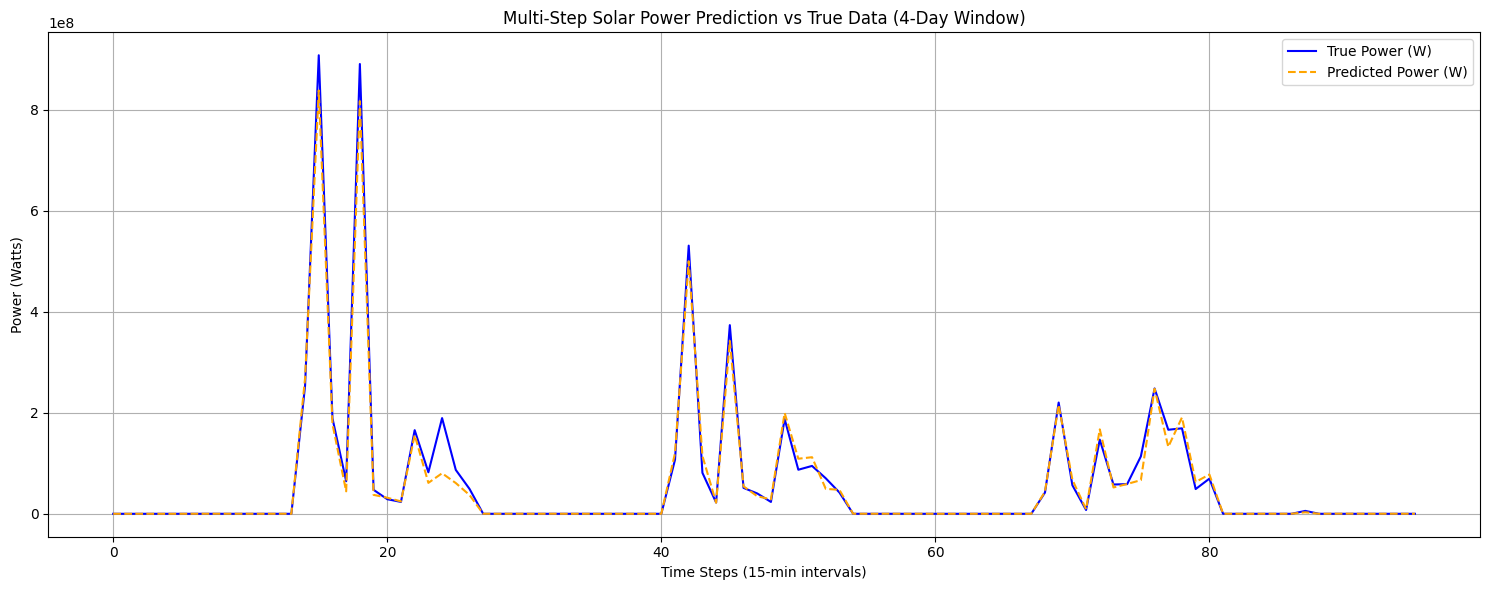

In [ ]:
# Define your prediction length (24 hours * 4 steps/hour = 96)
PRED_LENGTH = 96 

model_multi.eval()
all_preds = []
all_actuals = []

# 1. Gather all predictions from the test set
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        all_preds.append(model_multi(inputs).cpu().numpy())
        all_actuals.append(targets.cpu().numpy())

# Flatten and slice to create non-overlapping continuous data
preds_array = np.concatenate(all_preds)[::PRED_LENGTH].flatten()
actuals_array = np.concatenate(all_actuals)[::PRED_LENGTH].flatten()

# 2. Unscale using the helper function (Removes the redundant code block)
num_features = len(features)
preds_unscaled, actuals_unscaled = unscale_power_values(
    preds=preds_array, 
    actuals=actuals_array, 
    scaler=scaler, 
    target_idx=target_idx, 
    num_features=num_features
)

# 3. Calculate Validation Metrics 
daylight_mask = actuals_unscaled > 1.0

if np.sum(daylight_mask) > 0:
    mape = np.mean(np.abs((actuals_unscaled[daylight_mask] - preds_unscaled[daylight_mask]) / actuals_unscaled[daylight_mask])) * 100
    print(f"Average Percentage Deviation (MAPE - Daylight hours only): {mape:.2f}%")
else:
    print("Not enough daylight data to calculate meaningful percentage deviation.")

mae = np.mean(np.abs(actuals_unscaled - preds_unscaled))
nmae = (mae / actuals_unscaled.max()) * 100
print(f"Mean Absolute Error (MAE - All hours): {mae:.2f} Watts")
print(f"Normalised Mean Absolute Error (NMAE - All hours): {nmae:.2f}%")

# 4. Visualization (Plotting a 4-day window)
START_IDX = 96 * 130
PLOT_WINDOW = 96 * 4  # 4 days

# Safely handle if the non-overlapping test set is shorter than expected
if START_IDX + PLOT_WINDOW > len(actuals_unscaled):
    START_IDX = 0

plt.figure(figsize=(15, 6))
plt.plot(actuals_unscaled[START_IDX : START_IDX + PLOT_WINDOW], label='True Power (W)', color='blue', linewidth=1.5)
plt.plot(preds_unscaled[START_IDX : START_IDX + PLOT_WINDOW], label='Predicted Power (W)', color='orange', linestyle='--', linewidth=1.5)

plt.title('Multi-Step Solar Power Prediction vs True Data (4-Day Window)')
plt.xlabel('Time Steps (15-min intervals)')
plt.ylabel('Power (Watts)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# calculate residuals
residuals = preds_unscaled - actuals_unscaled


time_sin_idx = features.index('Time_Sin')

all_time_sin = []
model_multi.eval()
with torch.no_grad():
    for inputs, targets in test_loader:
        last_step_time_sin = inputs[:, -1, time_sin_idx].cpu().numpy()
        all_time_sin.append(last_step_time_sin)


time_sin_array = np.concatenate(all_time_sin)[::PRED_LENGTH].flatten()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


# Plot 1: Actual vs Predicted Scatter
axes.scatter(actuals_unscaled, preds_unscaled, alpha=0.3, color='dodgerblue', edgecolor='k', linewidth=0.5)
min_val = min(actuals_unscaled.min(), preds_unscaled.min())
max_val = max(actuals_unscaled.max(), preds_unscaled.max())

axes.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='y = x (Perfect Fit)')
axes.set_title('Actual vs Predicted Power')
axes.set_xlabel('Actual Power (W)')
axes.set_ylabel('Predicted Power (W)')
axes.legend()
axes.grid(True, alpha=0.3)


# Plot 2: Histogram of Residuals
axes.hist(residuals, bins=50, color='mediumorchid', edgecolor='black', alpha=0.7)
axes.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes.set_title('Distribution of Residuals')
axes.set_xlabel('Residual (Predicted - Actual) [W]')
axes.set_ylabel('Frequency')
axes.legend()
axes.grid(True, axis='y', alpha=0.3)


# Plot 3: Residuals vs Time_Sin
axes.scatter(time_sin_array, residuals, alpha=0.3, color='mediumseagreen', edgecolor='k', linewidth=0.5)
axes.axhline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes.set_title('Residuals vs Time of Day (Time_Sin)')
axes.set_xlabel('Time_Sin cyclical encoding')
axes.set_ylabel('Residual (Predicted - Actual) [W]')
axes.legend()
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6


Naive baseline testing

In [ ]:
# NAIVE & DAILY PERSISTENCE BASELINES
# ==========================================

print("Calculating Baselines...")

# Assuming your fully engineered dataset is stored in the variable 'merged_all'
# We create a lightweight copy to avoid altering the main dataset
baseline_df = merged_all[['power(W)']].copy()

# Baseline 1: Naive Persistence (Prediction_{t} = Actual_{t-1})
# "The power in 15 mins will be exactly what it is right now."
baseline_df['pred_15min_ahead'] = baseline_df['power(W)'].shift(1)

# Baseline 2: Daily Persistence (Prediction_{t} = Actual_{t-96})
# "The power right now will be exactly what it was 24 hours ago."
# Since data is at 15-min intervals, 24 hours = 96 steps.
baseline_df['pred_24hr_ahead'] = baseline_df['power(W)'].shift(96)

# Drop rows with NaNs (the first 96 rows) so both models are evaluated 
# on the exact same timeframe for a mathematically fair comparison.
baseline_df.dropna(inplace=True)

# Calculate evaluation metrics (Mean Absolute Error)
mae_15min = (baseline_df['power(W)'] - baseline_df['pred_15min_ahead']).abs().mean()
mae_24hr = (baseline_df['power(W)'] - baseline_df['pred_24hr_ahead']).abs().mean()

# Calculate Root Mean Squared Error
rmse_15min = ((baseline_df['power(W)'] - baseline_df['pred_15min_ahead'])**2).mean()**0.5
rmse_24hr = ((baseline_df['power(W)'] - baseline_df['pred_24hr_ahead'])**2).mean()**0.5

print("--- BASELINE 1: 15-Minute Naive Persistence ---")
print(f"MAE:  {mae_15min:.2f} W")
print(f"RMSE: {rmse_15min:.2f} W\n")

print("--- BASELINE 2: 24-Hour Daily Persistence ---")
print(f"MAE:  {mae_24hr:.2f} W")
print(f"RMSE: {rmse_24hr:.2f} W\n")

print("-" * 50)
print("GOAL: To prove it learned the weather physics, your deep learning model must beat the best of these two baselines!")

Calculating Baselines...
--- BASELINE 1: 15-Minute Naive Persistence ---
MAE:  640.13 W
RMSE: 1579.28 W

--- BASELINE 2: 24-Hour Daily Persistence ---
MAE:  1421.80 W
RMSE: 3304.23 W

--------------------------------------------------
GOAL: To prove it learned the weather physics, your deep learning model must beat the best of these two baselines!


Above:

Baseline testing

using a naive and seasonal persistance model

Naive: $Pred_t = Act_{t-1} $ i.e. prediction of power is what it was just now

Daily : $ Pred_t = Act_{t-96} $ i.e. prediction of power is what it was this time yesterday